# Mesa Commerce World  — RL Seller (Student Version)
## Big Data & AI
### Agentic AI
#### Dr. OScar Fuentes ofc1227@tec.mx

In this notebook you will build the reinforcement-learning solution from experience generated by the Mesa customer environment.


## 0. Imports

**Cómo ejecutar y qué se conserva.** En Google Colab usa **Runtime → Run all** (Entorno de ejecución → Ejecutar todas). Todo el código está en este notebook: no necesitas archivos `.py`, credenciales ni servicios de nube. Las clases `SourceAgent`, `BuyerAgent` y `CommerceWorld`, sus perfiles y sus reacciones son las del profesor. Se completa el adaptador de campañas y la ruta de Q-learning.

**Qué debes entender:** el simulador conoce el tipo de cliente y su estado interno; el vendedor sólo ve el perfil permitido, el canal, la respuesta previa y su presupuesto. Aprender implica decidir, observar el resultado y actualizar la tabla Q. Los resultados y archivos de entrega se generan al ejecutar las celdas finales.


In [1]:
%pip install -q mesa

import math
import json
from pathlib import Path
from collections import Counter
from IPython.display import display, Markdown

import mesa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Mesa:", mesa.__version__)
OUTPUT_DIR = Path("resultados_mesa_qlearning")
OUTPUT_DIR.mkdir(exist_ok=True)


Note: you may need to restart the kernel to use updated packages.


c:\Users\GJLG\Repositorios\Inteligencia artificial avanzada\Inteligencia-artificial-avanzada\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Mesa: 3.5.1


# 1. Global mock databases

In [2]:


INTERACTION_COLUMNS = [
    "step",
    "buyer_id",
    "archetype",
    "preferred_source",
    "source",
    "action",
    "price",
    "effective_price",
    "purchase_probability",
    "purchased",
    "money_before",
    "money_after",
    "salary",
    "pay_period",
    "steps_to_payday",
    "trust_before",
    "trust_after",
    "engagement_before",
    "engagement_after",
    "annoyance_before",
    "annoyance_after",
]

# Fast append-only simulation logs.
# We materialize these into Pandas DataFrames only when needed.
TRANSACTION_LOG = []
INTERACTION_LOG = []

# 2. Archetypes and personality traits

In [3]:

ARCHETYPES = {
    "Bargain Hunter": {
        "impulse": 3,
        "frugality": 5,
        "loyalty": 2,
        "curiosity": 3,
        "patience": 4,
        "sociality": 2,
        "skepticism": 3,
    },

    "Loyalist": {
        "impulse": 2,
        "frugality": 2,
        "loyalty": 5,
        "curiosity": 2,
        "patience": 4,
        "sociality": 3,
        "skepticism": 2,
    },

    "Explorer": {
        "impulse": 4,
        "frugality": 2,
        "loyalty": 2,
        "curiosity": 5,
        "patience": 3,
        "sociality": 3,
        "skepticism": 1,
    },

    "Trend Chaser": {
        "impulse": 5,
        "frugality": 1,
        "loyalty": 2,
        "curiosity": 4,
        "patience": 1,
        "sociality": 5,
        "skepticism": 1,
    },

    "Skeptic": {
        "impulse": 1,
        "frugality": 4,
        "loyalty": 2,
        "curiosity": 2,
        "patience": 5,
        "sociality": 1,
        "skepticism": 5,
    },
}

TRAIT_NAMES = list(next(iter(ARCHETYPES.values())).keys())

pd.DataFrame(ARCHETYPES).T


,impulse,frugality,loyalty,curiosity,patience,sociality,skepticism
Bargain Hunter,3,5,2,3,4,2,3
Loyalist,2,2,5,2,4,3,2
Explorer,4,2,2,5,3,3,1
Trend Chaser,5,1,2,4,1,5,1
Skeptic,1,4,2,2,5,1,5


# 3. Synthetic profile structure


The following dependencies are **synthetic simulator assumptions**, not claims about real people.

We use broad overlapping distributions so profile variables provide clues without deterministically revealing archetype.
  ### ALL VALUES ARE FICTIONAL AND DO NOT REPRESENT A POINT OF VIEW IN ANY WAY

In [4]:

COUNTRY_REGIONS = {
    "United States": [
        "California", "Texas", "New York", "Florida"
    ],
    "Canada": [
        "Ontario", "Quebec", "British Columbia", "Alberta"
    ],
    "Germany": [
        "Bavaria", "Berlin", "Hesse", "North Rhine-Westphalia"
    ],
    "United Kingdom": [
        "England", "Scotland", "Wales", "Northern Ireland"
    ],
    "Mexico": [
        "Ciudad de México", "Jalisco", "Nuevo León", "Puebla"
    ],
    "Brazil": [
        "São Paulo", "Rio de Janeiro", "Minas Gerais", "Paraná"
    ],
    "Colombia": [
        "Bogotá", "Antioquia", "Valle del Cauca", "Atlántico"
    ],
    "India": [
        "Maharashtra", "Delhi", "Karnataka", "Tamil Nadu"
    ],
}

# Available money distributions.
# These are deliberately overlapping ranges rather than deterministic labels.
COUNTRY_MONEY_RANGES = {
    "United States": (180, 650),
    "Canada": (170, 600),
    "Germany": (170, 600),
    "United Kingdom": (160, 580),
    "Mexico": (90, 360),
    "Brazil": (80, 330),
    "Colombia": (75, 300),
    "India": (70, 290),
}


# Synthetic salary distributions used by the simulation.
# Buyers receive salary periodically so long simulations do not
# collapse simply because every wallet eventually reaches zero.
COUNTRY_SALARY_RANGES = {
    "United States": (120, 260),
    "Canada": (110, 240),
    "Germany": (110, 240),
    "United Kingdom": (100, 230),
    "Mexico": (60, 150),
    "Brazil": (55, 140),
    "Colombia": (50, 130),
    "India": (45, 120),
}

SOURCE_TYPES = [
    "Search",
    "Organic",
    "Email",
    "Display",
    "Facebook",
]


# 4. Seller actions

In [5]:

NO_ACTION = "NO_ACTION"
SEND_DISCOUNT = "SEND_DISCOUNT"
RECOMMEND_PRODUCT = "RECOMMEND_PRODUCT"
LOYALTY_REWARD = "LOYALTY_REWARD"

SELLER_ACTIONS = [
    NO_ACTION,
    SEND_DISCOUNT,
    RECOMMEND_PRODUCT,
    LOYALTY_REWARD,
]


# 5. Traffic-source agents

In [6]:

class SourceAgent(mesa.Agent):

    def __init__(self, model, source_type):
        super().__init__(model)
        self.source_type = source_type


# 6. Buyer agent

## Simulated customer types

The world contains five hidden customer archetypes. These labels are used by the
simulator to generate behavior; the  reinforcement-learning seller will not
receive the label directly.

- **Bargain Hunter** — price sensitive; discounts tend to work best.
- **Loyalist** — responds strongly to loyalty rewards.
- **Explorer** — curious about new products; recommendations tend to work best.
- **Trend Chaser** — impulsive and socially responsive; recommendations are often effective.
- **Skeptic** — dislikes unnecessary intervention; doing nothing can be the best action.

Each individual customer is still different because the seven personality traits
are perturbed around the archetype profile. The archetype therefore describes a
tendency, not a deterministic rule.

## Agent State Transitions

The agent is modeled as a **state machine**. At any moment, the agent is in one state representing the current stage of its decision-making process. After completing the work associated with that state, it transitions to the next appropriate state.

This separates the agent's reasoning into explicit steps rather than treating the entire process as a single function call.

### Main decision loop

```text
OBSERVE_CUSTOMER
       ↓
    PREDICT
       ↓
ASSESS_CONTEXT
       ↓
     DECIDE
       ↓
      ACT
       ↓
WAIT_FOR_RESPONSE
       ↓
EVALUATE_OUTCOME
       ↓
     LEARN
       │
       └──────────────→ OBSERVE_CUSTOMER

## Buyer Agents: Persistent Internal State

Each buyer in the simulation is a **persistent agent**. A buyer does not simply generate an independent purchase decision at every interaction. Instead, the buyer has an internal state that evolves as they move through the simulated world and interact with the seller.

### Static characteristics

When a buyer is created, it receives characteristics that remain fixed during the simulation:

- **Demographic profile:** age, gender, country, state, signup month, and signup day.
- **Customer archetype:** Bargain Hunter, Loyalist, Explorer, Trend Chaser, or Skeptic.
- **Personality traits:** impulse, frugality, loyalty, curiosity, patience, sociality, and skepticism.
- **Preferred traffic source:** Search, Organic, Email, Display, or Facebook.
- **Salary:** periodic income used to replenish the buyer's available money.

These variables describe **who the buyer is**.

### Dynamic internal state

Other variables change throughout the simulation:

| State variable | Meaning |
|---|---|
| **money** | Current purchasing power. Purchases decrease it and salary payments replenish it. |
| **trust** | Current level of trust in the seller. Successful interactions can increase it; inappropriate actions can decrease it. |
| **engagement** | Current willingness to interact with the seller. |
| **annoyance** | Accumulated negative reaction to excessive or poorly matched interventions. |
| **purchase_count** | Number of purchases made by the buyer. |
| **total_spent** | Cumulative amount spent during the simulation. |

Therefore, an interaction produces a **state transition**:

```text
Current buyer state
(money, trust, engagement, annoyance)
             │
             ▼
     Encounter traffic source
             │
             ▼
       Seller action
             │
             ▼
     Purchase probability
             │
             ▼
       Buyer response
      purchase / no purchase
             │
             ▼
      Update internal state
             │
             ▼
       New buyer state

In [7]:
class BuyerAgent(mesa.Agent):
    """
    Simulated e-commerce customer.

    Observable profile fields resemble the customer attributes used elsewhere in
    the course. A hidden archetype and noisy personality traits determine how the
    customer reacts to different seller actions.

    Customer types used in this simulation:
      • Bargain Hunter  -> tends to react well to discounts
      • Loyalist        -> tends to react well to loyalty rewards
      • Explorer        -> tends to react well to product recommendations
      • Trend Chaser    -> tends to react well to product recommendations
      • Skeptic         -> tends to prefer little or no intervention

    The archetype is hidden from the RL seller agent. It is used only by the
    simulator to generate behavior.
    """

    def __init__(self, model):
        super().__init__(model)

        # --------------------------------------------------
        # Observable customer profile
        # --------------------------------------------------

        self.age = float(self.random.randint(18, 75))
        self.gender = self.random.choice(["F", "M"])

        self.country = self.random.choice(
            list(COUNTRY_REGIONS.keys())
        )

        self.state = self.random.choice(
            COUNTRY_REGIONS[self.country]
        )

        self.signup_month = float(
            self.random.randint(1, 12)
        )

        self.signup_day_of_week = float(
            self.random.randint(0, 6)
        )

        # Latent acquisition-channel preference.
        # It influences both archetype probability and movement in the world.
        self.preferred_source = self.random.choice(
            SOURCE_TYPES
        )

        # --------------------------------------------------
        # Hidden customer type
        # --------------------------------------------------

        self.archetype = self.choose_archetype()

        base = ARCHETYPES[self.archetype]

        self.traits = {
            trait: float(
                np.clip(
                    value + self.random.gauss(0, 0.55),
                    0,
                    5
                )
            )
            for trait, value in base.items()
        }

        # --------------------------------------------------
        # Customer finances
        # --------------------------------------------------

        low, high = COUNTRY_MONEY_RANGES[
            self.country
        ]

        self.money = round(
            self.random.uniform(low, high),
            2
        )

        salary_low, salary_high = COUNTRY_SALARY_RANGES[
            self.country
        ]

        self.salary = round(
            self.random.uniform(
                salary_low,
                salary_high
            ),
            2
        )

        # One synthetic pay cycle every 100 simulation steps.
        # Offsets are staggered so customers are paid on different steps.
        self.pay_period = 100
        self.pay_offset = self.random.randint(
            0,
            self.pay_period - 1
        )

        # --------------------------------------------------
        # Persistent internal customer state
        # --------------------------------------------------

        initial_state = {
            "Bargain Hunter": (0.45, 0.50, 0.05),
            "Loyalist":       (0.62, 0.55, 0.03),
            "Explorer":       (0.48, 0.65, 0.03),
            "Trend Chaser":   (0.42, 0.72, 0.04),
            "Skeptic":        (0.28, 0.28, 0.12),
        }

        (
            self.trust,
            self.engagement,
            self.annoyance,
        ) = initial_state[self.archetype]

        self.purchase_count = 0
        self.total_spent = 0.0

        self.hit_history = []
        self.action_history = []
        self.last_source = None

    # ------------------------------------------------------
    # Observable profile -> hidden archetype
    # ------------------------------------------------------

    def choose_archetype(self):

        weights = {
            "Bargain Hunter": 1.0,
            "Loyalist": 1.0,
            "Explorer": 1.0,
            "Trend Chaser": 1.0,
            "Skeptic": 1.0,
        }

        # Age contributes broad probabilistic clues.
        if self.age < 30:
            weights["Trend Chaser"] += 1.5
            weights["Explorer"] += 1.0

        elif self.age > 50:
            weights["Loyalist"] += 1.2
            weights["Skeptic"] += 0.9

        else:
            weights["Bargain Hunter"] += 0.4
            weights["Explorer"] += 0.3

        # Signup timing gives a mild signal.
        if self.signup_month >= 9:
            weights["Explorer"] += 0.5
            weights["Trend Chaser"] += 0.6

        elif self.signup_month <= 3:
            weights["Loyalist"] += 0.5

        # Preferred acquisition source is a stronger clue.
        if self.preferred_source == "Search":
            weights["Bargain Hunter"] += 1.2
            weights["Explorer"] += 0.8

        elif self.preferred_source == "Organic":
            weights["Explorer"] += 1.2
            weights["Skeptic"] += 0.8

        elif self.preferred_source == "Email":
            weights["Loyalist"] += 1.5
            weights["Bargain Hunter"] += 0.5

        elif self.preferred_source == "Display":
            weights["Trend Chaser"] += 1.3
            weights["Bargain Hunter"] += 0.4

        elif self.preferred_source == "Facebook":
            weights["Trend Chaser"] += 1.6
            weights["Explorer"] += 0.4

        # Weak synthetic country priors.
        if self.country in [
            "Mexico", "Brazil", "Colombia", "India"
        ]:
            weights["Bargain Hunter"] += 0.35

        if self.country in [
            "United States", "Canada", "Germany", "United Kingdom"
        ]:
            weights["Loyalist"] += 0.20

        # Small regional nudges prevent state/region from being pure noise.
        if self.state in ["California", "Berlin", "São Paulo"]:
            weights["Trend Chaser"] += 0.25

        if self.state in ["Texas", "Nuevo León", "Alberta"]:
            weights["Bargain Hunter"] += 0.20

        if self.state in ["Ontario", "England", "Bavaria"]:
            weights["Loyalist"] += 0.20

        archetypes = list(weights.keys())
        values = list(weights.values())

        return self.random.choices(
            archetypes,
            weights=values,
            k=1,
        )[0]

    # ------------------------------------------------------
    # Movement
    # ------------------------------------------------------

    def move(self):

        possible_steps = self.model.grid.get_neighborhood(
            self.pos,
            moore=False,
            include_center=False,
        )

        # Most movement remains exploratory.
        if self.random.random() < 0.70:
            new_position = self.random.choice(
                possible_steps
            )

        else:
            # Sometimes move toward the preferred acquisition source.
            target = self.model.source_positions[
                self.preferred_source
            ]

            def manhattan(pos):
                return (
                    abs(pos[0] - target[0])
                    + abs(pos[1] - target[1])
                )

            best_distance = min(
                manhattan(p)
                for p in possible_steps
            )

            best_steps = [
                p
                for p in possible_steps
                if manhattan(p) == best_distance
            ]

            new_position = self.random.choice(
                best_steps
            )

        self.model.grid.move_agent(
            self,
            new_position
        )

    # ------------------------------------------------------
    # Purchase tendency
    # ------------------------------------------------------

    def baseline_logit(self):

        t = {
            name: value / 5.0
            for name, value in self.traits.items()
        }

        personality_score = (
            0.25 * t["impulse"]
            + 0.20 * t["loyalty"]
            + 0.15 * t["curiosity"]
            + 0.10 * t["sociality"]
            + 0.10 * t["patience"]
            - 0.15 * t["skepticism"]
            - 0.05 * t["frugality"]
        )

        state_score = (
            + 0.90 * self.trust
            + 0.70 * self.engagement
            - 1.10 * self.annoyance
        )

        return (
            -2.50
            + 3.0 * personality_score
            + state_score
        )

    def action_effect(self, action):
        """
        Effect of the seller action on this customer's willingness to buy.

        The coefficients are intentionally strong enough that students can later
        observe a learned RL policy:
          Bargain Hunter -> SEND_DISCOUNT
          Explorer       -> RECOMMEND_PRODUCT
          Loyalist       -> LOYALTY_REWARD
          Trend Chaser   -> RECOMMEND_PRODUCT
          Skeptic        -> NO_ACTION
        """

        t = {
            name: value / 5.0
            for name, value in self.traits.items()
        }

        if action == SEND_DISCOUNT:
            return (
                + 1.60 * t["frugality"]
                + 0.45 * t["impulse"]
                - 0.80 * t["skepticism"]
            )

        if action == RECOMMEND_PRODUCT:
            return (
                + 1.60 * t["curiosity"]
                + 0.50 * t["impulse"]
                + 0.25 * t["sociality"]
                - 0.65 * t["skepticism"]
            )

        if action == LOYALTY_REWARD:
            return (
                + 1.80 * t["loyalty"]
                + 0.35 * t["patience"]
                - 0.30 * t["skepticism"]
            )

        # NO_ACTION can be the best treatment for highly skeptical customers.
        return (
            + 1.40 * t["skepticism"]
            + 0.30 * t["patience"]
            + 0.30 * self.annoyance
        )

    def source_effect(self):

        if self.last_source is None:
            return 0.0

        if self.last_source == self.preferred_source:
            return 0.45

        return -0.08

    def purchase_probability(self, action):

        logit = (
            self.baseline_logit()
            + self.action_effect(action)
            + self.source_effect()
        )

        return 1.0 / (
            1.0 + math.exp(-logit)
        )

    # ------------------------------------------------------
    # Internal-state reaction
    # ------------------------------------------------------

    def update_internal_state(
        self,
        action,
        purchased
    ):

        t = {
            name: value / 5.0
            for name, value in self.traits.items()
        }

        if action == SEND_DISCOUNT:
            fit = (
                + 0.75 * t["frugality"]
                + 0.25 * t["impulse"]
                - 0.60 * t["skepticism"]
            )

        elif action == RECOMMEND_PRODUCT:
            fit = (
                + 0.75 * t["curiosity"]
                + 0.25 * t["impulse"]
                - 0.55 * t["skepticism"]
            )

        elif action == LOYALTY_REWARD:
            fit = (
                + 0.85 * t["loyalty"]
                + 0.15 * t["patience"]
                - 0.35 * t["skepticism"]
            )

        else:
            # Leaving a skeptical customer alone can preserve trust.
            fit = (
                + 0.70 * t["skepticism"]
                + 0.20 * t["patience"]
            )

        if fit > 0.35:
            self.engagement += 0.10 + 0.08 * fit
            self.trust += 0.07 + 0.06 * fit
            self.annoyance -= 0.05

        elif fit < 0.05:
            self.annoyance += (
                0.10
                + 0.08 * abs(fit)
            )
            self.trust -= 0.05

        else:
            self.engagement += 0.02

        if purchased:
            self.engagement += 0.08
            self.trust += 0.05
            self.annoyance -= 0.03

        # Repeating the same intervention too often can create fatigue.
        if len(self.action_history) >= 3:

            last_three = self.action_history[-3:]

            if (
                action != NO_ACTION
                and len(set(last_three)) == 1
            ):
                self.annoyance += 0.08

        self.trust = float(
            np.clip(self.trust, 0.0, 1.0)
        )

        self.engagement = float(
            np.clip(self.engagement, 0.0, 1.0)
        )

        self.annoyance = float(
            np.clip(self.annoyance, 0.0, 1.0)
        )

    # ------------------------------------------------------
    # Long-run dynamics
    # ------------------------------------------------------

    def receive_salary(self):
        """Deposit periodic synthetic salary."""
        self.money += self.salary

    def steps_to_payday(self):
        """Return the number of simulation steps until the next payday."""

        remainder = (
            self.model.step_count
            - self.pay_offset
        ) % self.pay_period

        if remainder == 0:
            return 0

        return (
            self.pay_period
            - remainder
        )

    def decay_internal_state(self):
        """
        Slowly move relationship variables toward neutral values.

        This prevents trust, engagement, or annoyance from becoming permanently
        saturated during very long simulations.
        """

        self.trust += (
            0.01
            * (0.50 - self.trust)
        )

        self.engagement += (
            0.01
            * (0.40 - self.engagement)
        )

        self.annoyance *= 0.98

        self.trust = float(
            np.clip(self.trust, 0.0, 1.0)
        )

        self.engagement = float(
            np.clip(self.engagement, 0.0, 1.0)
        )

        self.annoyance = float(
            np.clip(self.annoyance, 0.0, 1.0)
        )

    # ------------------------------------------------------
    # Transaction
    # ------------------------------------------------------

    def transact(self, effective_price):

        global TRANSACTION_LOG

        if self.money < effective_price:
            return False

        self.money -= effective_price
        self.total_spent += effective_price
        self.purchase_count += 1

        transaction = {
            "age": self.age,
            "gender": self.gender,
            "country": self.country,
            "state": self.state,
            "traffic_source": self.last_source,
            "signup_month": self.signup_month,
            "signup_day_of_week": self.signup_day_of_week,
        }

        TRANSACTION_LOG.append(
            transaction
        )

        return True

    # ------------------------------------------------------
    # Seller action -> response -> transaction
    # ------------------------------------------------------

    def react(
        self,
        action,
        base_price=40.0
    ):

        global INTERACTION_LOG

        self.action_history.append(
            action
        )

        if action == SEND_DISCOUNT:
            effective_price = (
                base_price * 0.80
            )

        elif action == LOYALTY_REWARD:
            effective_price = (
                base_price * 0.90
            )

        else:
            effective_price = base_price

        money_before = self.money
        trust_before = self.trust
        engagement_before = self.engagement
        annoyance_before = self.annoyance

        p_purchase = (
            self.purchase_probability(
                action
            )
        )

        wants_to_buy = (
            self.random.random()
            < p_purchase
        )

        purchased = False

        if wants_to_buy:
            purchased = self.transact(
                effective_price
            )

        self.update_internal_state(
            action,
            purchased
        )

        INTERACTION_LOG.append({
            "step": self.model.step_count,
            "buyer_id": self.unique_id,
            "archetype": self.archetype,
            "preferred_source": self.preferred_source,
            "source": self.last_source,
            "action": action,
            "price": base_price,
            "effective_price": effective_price,
            "purchase_probability": p_purchase,
            "purchased": purchased,
            "money_before": money_before,
            "money_after": self.money,
            "salary": self.salary,
            "pay_period": self.pay_period,
            "steps_to_payday": self.steps_to_payday(),
            "trust_before": trust_before,
            "trust_after": self.trust,
            "engagement_before": engagement_before,
            "engagement_after": self.engagement,
            "annoyance_before": annoyance_before,
            "annoyance_after": self.annoyance,
        })

        return purchased

    # ------------------------------------------------------
    # Traffic-source encounter
    # ------------------------------------------------------

    def check_source(self):

        self.last_source = None

        cellmates = (
            self.model.grid
            .get_cell_list_contents(
                [self.pos]
            )
        )

        for agent in cellmates:

            if isinstance(
                agent,
                SourceAgent
            ):

                self.last_source = (
                    agent.source_type
                )

                self.hit_history.append(
                    agent.source_type
                )

                self.model.source_hits[
                    agent.source_type
                ] += 1

                action = (
                    self.model.choose_action(
                        self
                    )
                )

                self.react(
                    action=action,
                    base_price=self.model.base_price
                )

    def step(self):
        """Advance this customer by one simulation step."""

        self.decay_internal_state()
        self.move()
        self.check_source()

# 7. Commerce world

In [8]:
class CommerceWorld(mesa.Model):
    """
    E-commerce simulation world.

    Fifty customer agents move through a 10x10 grid containing five acquisition
    sources: Search, Organic, Email, Display, and Facebook.

    When a customer reaches a source, the seller chooses one intervention:
      • NO_ACTION
      • SEND_DISCOUNT
      • RECOMMEND_PRODUCT
      • LOYALTY_REWARD

    The current seller is deliberately random. Later, this method becomes the
    decision point controlled by the reinforcement-learning agent.
    """

    def __init__(
        self,
        width=10,
        height=10,
        n_buyers=50,
        base_price=40.0,
        seed=42,
    ):
        super().__init__(seed=seed)

        self.width = width
        self.height = height
        self.base_price = float(base_price)

        self.grid = mesa.space.MultiGrid(
            width,
            height,
            torus=False
        )

        self.step_count = 0

        self.source_positions = {
            "Search":   (1, 8),
            "Organic":  (8, 8),
            "Email":    (5, 5),
            "Display":  (1, 1),
            "Facebook": (8, 1),
        }

        self.source_hits = {
            source: 0
            for source in SOURCE_TYPES
        }

        self.sources = []
        self.buyers = []

        # Create traffic-source agents.
        for source_type, pos in self.source_positions.items():

            source = SourceAgent(
                self,
                source_type
            )

            self.sources.append(source)

            self.grid.place_agent(
                source,
                pos
            )

        # Create customer agents.
        for _ in range(n_buyers):

            buyer = BuyerAgent(self)

            self.buyers.append(buyer)

            pos = (
                self.random.randrange(width),
                self.random.randrange(height)
            )

            self.grid.place_agent(
                buyer,
                pos
            )

    def choose_action(self, buyer):
        """
        Random seller baseline.

        The hidden archetype is intentionally NOT used here. The future RL
        seller must learn useful behavior from observations and outcomes.
        """
        return self.random.choice(
            SELLER_ACTIONS
        )

    def step(self):
        """Advance the complete simulated market by one time step."""

        # 1) Customers move and may interact with the seller.
        buyers = self.buyers.copy()
        self.random.shuffle(buyers)

        for buyer in buyers:
            buyer.step()

        # 2) Advance the shared simulation clock.
        self.step_count += 1

        # 3) Staggered payday.
        # Every buyer is paid every 100 steps, but each has a different offset.
        for buyer in self.buyers:

            if (
                self.step_count - buyer.pay_offset
            ) % buyer.pay_period == 0:

                buyer.receive_salary()

# 8. Del perfil observable al estado del vendedor

Conservamos el proxy local del notebook base. **`local_nn_proxy` es una fórmula heurística sintética, no una red neuronal entrenada ni una probabilidad calibrada.** Sólo resume campos observables; nunca consulta `archetype`, rasgos de personalidad, dinero, salario, confianza, engagement o molestia.

Usaremos un estado de cuatro componentes:

```python
estado = (bucket_cliente, fuente_trafico, respuesta_previa, presupuesto_restante)
```

| Variable | Qué representa y cómo se obtiene |
|---|---|
| `bucket_cliente` | `LOW` si el score es menor que 0.30; `MEDIUM` si está entre 0.30 y 0.60; `HIGH` si es al menos 0.60. Se calcula con el perfil observable y el canal actual. |
| `fuente_trafico` | El canal observado del contacto: Search, Organic, Email, Display o Facebook. No es la preferencia oculta del comprador. |
| `respuesta_previa` | último resultado registrado para **ese comprador**: NONE, PURCHASE o NO_PURCHASE. NONE significa que aún no se le ha contactado en esta campaña. |
| `presupuesto_restante` | Dinero disponible para pagar contactos. Se conserva exactamente, sin agruparlo, para rechazar acciones que no podemos pagar. |

Con presupuesto 100 y costos múltiplos de 2 hay **50 presupuestos positivos** (2, 4, ..., 100). La tabla contiene $3\times5\times3\times50=2250$ estados de decisión y **un estado terminal**, es decir, **2251 estados y 9004 valores Q**. El cero se representa exclusivamente como terminal. Es un máximo de combinaciones: no todas son alcanzables; por ejemplo, el proxy nunca llega a HIGH en Organic, Display o Facebook.

**Por qué sirve y cuál es su límite:** es una representación pequeña, auditable y contiene la restricción económica. La respuesta previa añade una señal del historial. Aun así, pierde información sobre compras acumuladas, fatiga, otros compradores y tiempo hasta el final: el entorno es parcialmente observable y la representación no garantiza la propiedad de Markov ni la convergencia a la política óptima.


**Estado terminal:** `TERMINAL_STATE` es un marcador compartido para ambos motivos de finalización. Su último componente es cero por convención; si la campaña terminó por el límite de contactos puede quedar dinero. El presupuesto realmente sobrante se conserva en `info["budget_remaining"]` y en el CSV.


In [9]:
import itertools
from collections import defaultdict

P_BUCKETS = ["LOW", "MEDIUM", "HIGH"]
RESPONSES = ["NONE", "PURCHASE", "NO_PURCHASE"]
INITIAL_BUDGET = 100
MAX_INTERACTIONS = 40
N_BUYERS_CAMPAIGN = 6
BASE_PRICE = 40.0
TERMINAL_STATE = ("TERMINAL", "TERMINAL", "TERMINAL", 0)


def conversion_bucket(p):
    if p < 0.30:
        return "LOW"
    if p < 0.60:
        return "MEDIUM"
    return "HIGH"


def observable_profile(buyer, source):
    return {
        "age": buyer.age,
        "gender": buyer.gender,
        "country": buyer.country,
        "state": buyer.state,
        "traffic_source": source,
        "signup_month": buyer.signup_month,
        "signup_day_of_week": buyer.signup_day_of_week,
    }


def local_nn_proxy(profile):
    # Fórmula ORIGINAL del profesor. No utiliza información oculta.
    z = -1.80
    z += 0.70 if profile["traffic_source"] in ["Search", "Email"] else 0.0
    z += 0.60 if profile["signup_month"] >= 9 else 0.0
    z += 0.30 if profile["signup_month"] <= 3 else 0.0
    z += 0.45 if profile["age"] < 30 else 0.0
    z += 0.25 if profile["age"] > 50 else 0.0
    z += 0.45 if profile["country"] in ["United States", "Canada", "Germany", "United Kingdom"] else 0.0
    z += 0.25 if profile["signup_day_of_week"] >= 5 else 0.0
    return float(1.0 / (1.0 + np.exp(-z)))


def cached_or_local_prediction(buyer, source, prediction_cache=None):
    profile = observable_profile(buyer, source)
    if prediction_cache is None:
        return local_nn_proxy(profile)
    # Compatibilidad con un diccionario local: ningún servicio externo.
    key = tuple(profile.values())
    return float(prediction_cache[key])


BUDGET_LEVELS = list(range(2, INITIAL_BUDGET + 1, 2))
STATES = list(itertools.product(P_BUCKETS, SOURCE_TYPES, RESPONSES, BUDGET_LEVELS))
STATES.append(TERMINAL_STATE)
STATE_TO_INDEX = {state: i for i, state in enumerate(STATES)}
ACTION_TO_INDEX = {action: i for i, action in enumerate(SELLER_ACTIONS)}
N_STATES, N_ACTIONS = len(STATES), len(SELLER_ACTIONS)
print("Estados:", N_STATES, "| Acciones:", N_ACTIONS, "| Entradas Q:", N_STATES * N_ACTIONS)


Estados: 2251 | Acciones: 4 | Entradas Q: 9004


**Importante: ejecución local y sin fuga de información.** Usaremos `prediction_cache = None`, de modo que el score sale del proxy original y todo funciona sin GCP. El simulador utiliza sus características ocultas para producir una reacción; esas características no se incorporan al estado, al selector de acciones ni a la actualización Q. Los resultados de compra sí son observables después de actuar.


In [10]:
prediction_cache = None  # Sólo se usa el proxy local del notebook base.


# 9. Adaptador de campañas sobre los compradores reales de Mesa

El adaptador conserva la idea del original: crea `CommerceWorld` y llama directamente a **`BuyerAgent.react()`**. Una campaña tiene seis compradores persistentes y hasta 40 contactos, con presupuesto inicial de **100 unidades monetarias (u.m.)**. La agenda selecciona un comprador y un canal por contacto con un generador independiente. El resultado previo se guarda por comprador.

Como en el adaptador base, un paso de RL es un **contacto comercial programado**; no se ejecuta el paseo espacial de `CommerceWorld.step()`. Las compras, rebajas, finanzas y reacciones internas sí provienen del código original de Mesa. Se conserva el salario periódico del simulador y se avanza su reloj. Este supuesto debe mencionarse al interpretar los resultados.

| Acción | Costo por contacto (u.m.) | Precio si ocurre una venta (u.m.) |
|---|---:|---:|
| NO_ACTION | 0 | 40 |
| SEND_DISCOUNT | 8 | 32 |
| RECOMMEND_PRODUCT | 2 | 40 |
| LOYALTY_REWARD | 4 | 36 |

**Justificación:** los costos de contacto son cuatro veces los costos originales de las acciones activas, para representar niveles distintos de gasto y hacer relevante un presupuesto de 100 dentro de 40 contactos. Son supuestos sintéticos fijados antes de evaluar. NO_ACTION cuesta cero como desembolso, porque no se paga una intervención. Para evitar que las compras espontáneas vuelvan trivial la política, añadimos **una penalización didáctica de 12 u.m. (30% del precio base) cuando NO_ACTION no consigue una compra**. Es un supuesto de oportunidad perdida, **no una venta perdida observada ni dinero gastado**. No se descuenta del presupuesto. Su tamaño debe justificarse y probarse con datos reales antes de usarlo fuera del ejercicio. Las rebajas del 20% y 10% se mantienen como en `BuyerAgent.react()`.

La recompensa se calcula **después de la respuesta del comprador**, una vez por contacto:

$$r_t = \underbrace{\mathbb{1}(\text{compra})\,\text{precio efectivo}}_{\text{ingreso cobrado}} - \text{costo del contacto} - 12\,\mathbb{1}(a_t=\text{NO_ACTION y no hubo compra}).$$

Una recomendación sin compra da −2 u.m.; un descuento con compra da 32 − 8 = 24 u.m. **No descontamos la rebaja dos veces:** ya reduce el precio efectivo. El presupuesto sólo financia contactos; los ingresos no lo recargan. El **retorno ajustado** de campaña es la suma de estas recompensas; no equivale a flujo de caja. También reportamos **retorno contable = ingreso − costo de acciones**, separado de la penalización ficticia. Por ejemplo, NO_ACTION sin compra da −12 u.m. de recompensa aunque el presupuesto no cambie; si sí hay compra, da 40 u.m. La penalización intenta promover intervenciones justificadas, pero no permite afirmar que se habría logrado una venta de haber actuado. Aún faltan costos de producto, envío y devoluciones para medir utilidad empresarial.

El episodio termina si el presupuesto llega a cero o se realizan 40 contactos. Con NO_ACTION gratuito, el límite de contactos impide campañas infinitas. Sólo se permiten acciones cuyo costo no supere el presupuesto restante, también al calcular el máximo futuro de Q.


In [11]:
ACTION_CONTACT_COST = {
    NO_ACTION: 0,
    SEND_DISCOUNT: 8,
    RECOMMEND_PRODUCT: 2,
    LOYALTY_REWARD: 4,
}
# Supuesto educativo: oportunidad no aprovechada al no intervenir y no vender.
MISSED_OPPORTUNITY_PENALTY = 12.0  # 30% de BASE_PRICE; no consume presupuesto.


def valid_action_indices(state):
    if state == TERMINAL_STATE:
        return np.array([], dtype=int)
    budget = state[3]
    return np.array([i for i, a in enumerate(SELLER_ACTIONS)
                     if ACTION_CONTACT_COST[a] <= budget], dtype=int)


class MesaSellerEnv:
    def __init__(self, episode_length=MAX_INTERACTIONS,
                 initial_budget=INITIAL_BUDGET, n_buyers=N_BUYERS_CAMPAIGN,
                 prediction_cache=None, seed=42):
        if initial_budget != INITIAL_BUDGET:
            raise ValueError("Para cambiar el presupuesto, reconstruye STATES y la tabla Q.")
        if episode_length < 1 or n_buyers < 1:
            raise ValueError("Se necesita al menos un contacto y un comprador.")
        self.episode_length = episode_length
        self.initial_budget = initial_budget
        self.n_buyers = n_buyers
        self.prediction_cache = prediction_cache
        self.seed_value = seed
        self.world = None
        self.done = True

    def reset(self, seed=None):
        if seed is not None:
            self.seed_value = int(seed)
        self.rng = np.random.default_rng(self.seed_value)
        # Los registros globales son los del profesor; sólo se conservan
        # los de la campaña actual para evitar acumular millones en memoria.
        TRANSACTION_LOG.clear()
        INTERACTION_LOG.clear()
        self.world = CommerceWorld(width=10, height=10, n_buyers=self.n_buyers,
                                   base_price=BASE_PRICE, seed=self.seed_value)
        self.previous_responses = ["NONE"] * self.n_buyers
        self.episode_step = 0
        self.budget_remaining = self.initial_budget
        self.done = False
        # Agenda fija por semilla, independiente de las acciones elegidas.
        self.buyer_schedule = self.rng.integers(0, self.n_buyers, self.episode_length)
        self.source_schedule = self.rng.integers(0, len(SOURCE_TYPES), self.episode_length)
        self._next_contact()
        return self._state()

    def _next_contact(self):
        self.buyer_index = int(self.buyer_schedule[self.episode_step])
        self.buyer = self.world.buyers[self.buyer_index]
        self.source = SOURCE_TYPES[int(self.source_schedule[self.episode_step])]

    def _prediction(self):
        return cached_or_local_prediction(self.buyer, self.source, self.prediction_cache)

    def _state(self):
        if self.done:
            return TERMINAL_STATE
        return (conversion_bucket(self._prediction()), self.source,
                self.previous_responses[self.buyer_index], self.budget_remaining)

    def step(self, action):
        if self.done:
            raise RuntimeError("La campaña terminó. Usa reset() antes de actuar.")
        if action not in ACTION_CONTACT_COST:
            raise ValueError(f"Acción desconocida: {action}")
        cost = ACTION_CONTACT_COST[action]
        if cost > self.budget_remaining:
            raise ValueError("La acción cuesta más que el presupuesto restante.")
        budget_before = self.budget_remaining
        self.buyer.decay_internal_state()
        self.buyer.last_source = self.source
        self.buyer.hit_history.append(self.source)
        self.world.source_hits[self.source] += 1
        purchased = self.buyer.react(action, base_price=self.world.base_price)
        interaction = INTERACTION_LOG[-1]
        income = float(interaction["effective_price"]) if purchased else 0.0
        opportunity_penalty = (MISSED_OPPORTUNITY_PENALTY
                               if action == NO_ACTION and not purchased else 0.0)
        reward = income - cost - opportunity_penalty
        self.budget_remaining -= cost
        self.previous_responses[self.buyer_index] = "PURCHASE" if purchased else "NO_PURCHASE"
        buyer_id = self.buyer.unique_id
        self.episode_step += 1
        self.world.step_count += 1
        for buyer in self.world.buyers:
            if (self.world.step_count - buyer.pay_offset) % buyer.pay_period == 0:
                buyer.receive_salary()
        self.done = (self.budget_remaining == 0 or self.episode_step >= self.episode_length)
        reason = ("presupuesto_agotado" if self.budget_remaining == 0 else
                  "limite_interacciones" if self.done else "")
        info = {"purchased": bool(purchased), "income": income, "action_cost": cost,
                "effective_price": float(interaction["effective_price"]),
                "opportunity_penalty": opportunity_penalty,
                "budget_before": budget_before, "budget_remaining": self.budget_remaining,
                "buyer_id": buyer_id, "termination_reason": reason}
        if not self.done:
            self._next_contact()
        return self._state(), float(reward), self.done, info


In [12]:
env = MesaSellerEnv(prediction_cache=prediction_cache, seed=42)
state = env.reset()
next_state, reward, done, info = env.step(RECOMMEND_PRODUCT)
print("Estado observable:", state)
print("Siguiente estado:", next_state)
print("Recompensa:", reward, "u.m. | Compra:", info["purchased"])
print("Presupuesto restante:", info["budget_remaining"], "u.m.")
print("Compradores Mesa en la campaña:", len(env.world.buyers))
assert isinstance(env.buyer, BuyerAgent) and isinstance(env.world, mesa.Model)
assert reward == info["income"] - info["action_cost"] - info["opportunity_penalty"]


Estado observable: ('MEDIUM', 'Search', 'NONE', 100)
Siguiente estado: ('LOW', 'Display', 'NONE', 98)
Recompensa: -2.0 u.m. | Compra: False
Presupuesto restante: 98 u.m.
Compradores Mesa en la campaña: 6


c:\Users\GJLG\Repositorios\Inteligencia artificial avanzada\Inteligencia-artificial-avanzada\.venv\Lib\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


# 10. Políticas base

Conservamos las tres políticas del notebook: no intervenir, elegir al azar y aplicar reglas observables. La aleatoria explora uniformemente **entre acciones asequibles**. La heurística recomienda según canal y respuesta previa; si no puede pagar su acción, usa NO_ACTION. Ninguna consulta el arquetipo oculto. Evaluar también NO_ACTION nos permite comprobar si el simulador recompensa principalmente ahorrar contactos.


In [13]:
def no_action_policy(state, rng=None):
    return NO_ACTION


def random_policy(state, rng):
    return SELLER_ACTIONS[int(rng.choice(valid_action_indices(state)))]


def observable_heuristic_policy(state, rng=None):
    bucket, source, previous_response, budget = state
    if previous_response == "PURCHASE":
        action = NO_ACTION
    elif bucket == "LOW" and source in ["Search", "Display"]:
        action = SEND_DISCOUNT
    elif source in ["Organic", "Facebook"]:
        action = RECOMMEND_PRODUCT
    elif source == "Email":
        action = LOYALTY_REWARD
    else:
        action = NO_ACTION
    return action if ACTION_CONTACT_COST[action] <= budget else NO_ACTION


# 11. De las interacciones a las transiciones

Cada contacto produce $(s_t,a_t,r_t,s_{t+1},\text{terminado})$. **El siguiente estado describe el siguiente contacto programado**, que puede corresponder a otro comprador; no es necesariamente el estado interno actualizado del mismo cliente.

Guardamos episodio, paso, semilla, estado, acción, recompensa, siguiente estado, terminado, presupuesto restante y compra. Añadimos ingreso, costo, penalización por no actuar sin compra, precio efectivo e identificador del comprador para auditar la recompensa y distinguirla del presupuesto real. Durante el entrenamiento registraremos además epsilon y los valores Q antes y después de cada actualización. No incluimos información oculta en las entradas del agente.

`collect_experience` conserva la demostración aleatoria de la base con sólo tres campañas. El **dataset de entrega `experience_df`** se construye después con las interacciones reales del vendedor epsilon-greedy durante el aprendizaje; la demostración no se reutiliza como entrenamiento.


In [14]:
def collect_experience(env, episodes=3, seed=100):
    records = []
    rng = np.random.default_rng(seed)
    for episode in range(episodes):
        state = env.reset(seed=seed + episode)
        while True:
            action = random_policy(state, rng)
            next_state, reward, done, info = env.step(action)
            records.append({"episode": episode + 1, "step": env.episode_step,
                            "campaign_seed": seed + episode, "state": state,
                            "action": action, "reward": reward, "next_state": next_state,
                            "done": done, **info})
            state = next_state
            if done:
                break
    return pd.DataFrame(records)


demo_experience_df = collect_experience(env)
print("Transiciones de demostración:", len(demo_experience_df))
display(demo_experience_df.head())


Transiciones de demostración: 91


,episode,step,campaign_seed,state,action,reward,next_state,done,purchased,income,action_cost,effective_price,opportunity_penalty,budget_before,budget_remaining,buyer_id,termination_reason
0,1,1,100,"(MEDIUM, Organic, NONE, 100)",LOYALTY_REWARD,32.0,"(LOW, Facebook, NONE, 96)",False,True,36.0,4,36.0,0.0,100,96,10,
1,1,2,100,"(LOW, Facebook, NONE, 96)",LOYALTY_REWARD,32.0,"(MEDIUM, Email, NONE, 92)",False,True,36.0,4,36.0,0.0,96,92,11,
2,1,3,100,"(MEDIUM, Email, NONE, 92)",NO_ACTION,40.0,"(MEDIUM, Facebook, NONE, 92)",False,True,40.0,0,40.0,0.0,92,92,6,
3,1,4,100,"(MEDIUM, Facebook, NONE, 92)",RECOMMEND_PRODUCT,-2.0,"(MEDIUM, Facebook, PURCHASE, 90)",False,False,0.0,2,40.0,0.0,92,90,9,
4,1,5,100,"(MEDIUM, Facebook, PURCHASE, 90)",NO_ACTION,40.0,"(LOW, Organic, NONE, 90)",False,True,40.0,0,40.0,0.0,90,90,6,


**Contexto conservado de la base.** Las secciones 12 y 13 describen la ruta alternativa basada en un modelo estimado. La actividad actual se resuelve con la ruta B, Q-learning, por lo que no es necesario implementar estas alternativas.

# 12. Path A — estimate an MDP model and propagate value

One way to solve the problem is to transform the sampled transitions into an empirical Markov Decision Process.

From `experience_df`, estimate:

$
P(s'\mid s,a)
$

and

$
R(s,a)=\mathbb{E}[r\mid s,a].
$

For every state-action pair, count how often each next state was observed and normalize those counts to obtain a transition probability distribution. The reward matrix should contain the mean observed reward for that same state-action pair.

### Your task

Create:

- `P` with shape `(N_STATES, N_ACTIONS, N_STATES)`
- `R` with shape `(N_STATES, N_ACTIONS)`

Check that every observed `(state, action)` row of `P` sums approximately to 1.


## Policy iteration

Once you have $P$ and $R$, evaluate and improve a policy using the Bellman expectation equation:

$
V_\pi(s)=R(s,\pi(s))+\gamma\sum_{s'}P(s'\mid s,\pi(s))V_\pi(s').
$

Then improve the policy by selecting the action with the largest action value:

$
Q(s,a)=R(s,a)+\gamma\sum_{s'}P(s'\mid s,a)V(s').
$

Implement the update using ordinary loops and a dot product such as `P[s_idx, a_idx].dot(values)` so the relationship with the equation remains visible.

**Deliverable:** `pi_policy`, one action index for every state.


# 13. Value iteration

A second model-based solution is value iteration. Instead of evaluating one fixed policy first, repeatedly apply the Bellman optimality update:

$
V_{k+1}(s)=\max_a\left[R(s,a)+\gamma\sum_{s'}P(s'\mid s,a)V_k(s')\right].
$

Iterate until the maximum change in $V$ is smaller than a tolerance, then extract the greedy policy.

**Deliverable:** `vi_policy` and a short plot or table showing convergence.


**Ruta opcional del notebook original:** value iteration utiliza P y R estimados. Nuestra entrega implementa Q-learning explícito en la siguiente sección; no utiliza P ni R ni necesita estas alternativas para ejecutarse.


# 14. Path B — learn directly from transitions with Q-learning

Q-learning does **not** require an explicit transition matrix $P$ or reward matrix $R$.

Instead, it can learn directly from the observed tuples

$
(s,a,r,s').
$

For each transition, update:

$
Q(s,a)\leftarrow Q(s,a)+\alpha\left[r+\gamma\max_{a'}Q(s',a')-Q(s,a)\right].
$

You may train from fresh interactions with `env.step(...)` or iterate over the transitions in `experience_df`. If you interact with the environment directly, use an $\epsilon$-greedy strategy so the seller continues exploring actions while learning.

**Deliverable:** `q_policy`, obtained by taking the best learned action for every state.


## Implementación explícita de Q-learning

**Qué representa Q:** $Q(s,a)$ estima la **recompensa ajustada descontada** esperada de ejecutar una acción y continuar decidiendo. Incluye la penalización didáctica por NO_ACTION sin venta; no es una probabilidad de compra ni dinero efectivamente recibido.

Para una transición no terminal:

$$Q(s,a)\leftarrow Q(s,a)+\alpha\left[r+\gamma\max_{a'\text{ asequible}}Q(s',a')-Q(s,a)\right].$$

Si la campaña terminó, la meta es sólo la recompensa observada:

$$Q(s,a)\leftarrow Q(s,a)+\alpha\left[r-Q(s,a)\right].$$

| Parámetro | Valor base | Significado |
|---|---:|---|
| Episodios | 6000 | Campañas nuevas para aprender. |
| $\alpha$ | 0.10 | Fracción del error que corrige cada actualización. |
| $\gamma$ | 0.95 | Peso de recompensas futuras. Se comparará con 0.0 en el experimento. |
| $\epsilon$ inicial | 1.00 | Al principio todas las decisiones exploran. |
| $\epsilon$ mínimo | 0.05 | Mantiene algo de exploración al final. |
| Reducción | Exponencial durante el primer 70% de episodios | Después se mantiene en 0.05. |

**Epsilon-greedy:** con probabilidad epsilon probamos una acción asequible al azar; de lo contrario elegimos la de mayor Q. Los empates se resuelven por el orden de `SELLER_ACTIONS`; en estados sin experiencia esto favorece NO_ACTION. Se reporta esta limitación. La tabla empieza en cero; el registro de cada transición muestra cómo cambia el valor usado.

**Objetivo y descuento:** el criterio de evaluación principal es la suma **sin descuento** de ingresos menos costos y menos la penalización sintética. También se reporta ingreso menos costos sin penalización para no confundir la recompensa con dinero real. Usar gamma=0.95 introduce una preferencia por ingresos tempranos, que no coincide exactamente con ese criterio. El experimento permitirá analizar cuánto importa esta decisión.


In [15]:
EPISODES_TRAIN = 6000
ALPHA = 0.10
GAMMA = 0.95
EPSILON_INITIAL = 1.0
EPSILON_MIN = 0.05
TRAIN_SEED_START = 1000
AGENT_SEED = 31415


def epsilon_at(episode, episodes):
    decay_episodes = max(1, round(0.70 * episodes) - 1)
    fraction = min(episode / decay_episodes, 1.0)
    return float(EPSILON_INITIAL * (EPSILON_MIN / EPSILON_INITIAL) ** fraction)


def epsilon_greedy(Q, state, epsilon, rng):
    valid = valid_action_indices(state)
    if len(valid) == 0:
        raise ValueError("El estado terminal no admite decisiones.")
    if rng.random() < epsilon:
        action_index = int(rng.choice(valid))
    else:
        state_index = STATE_TO_INDEX[state]
        action_index = int(valid[np.argmax(Q[state_index, valid])])
    return SELLER_ACTIONS[action_index]


def update_q(Q, state, action, reward, next_state, done, alpha, gamma):
    s = STATE_TO_INDEX[state]
    a = ACTION_TO_INDEX[action]
    q_before = float(Q[s, a])
    if done:
        target = float(reward)  # Ningún valor futuro después del final.
    else:
        next_valid = valid_action_indices(next_state)
        next_s = STATE_TO_INDEX[next_state]
        target = float(reward + gamma * np.max(Q[next_s, next_valid]))
    Q[s, a] = q_before + alpha * (target - q_before)
    return q_before, target, float(Q[s, a])


def train_q_learning(episodes=EPISODES_TRAIN, alpha=ALPHA, gamma=GAMMA,
                     seed_start=TRAIN_SEED_START, agent_seed=AGENT_SEED,
                     record_transitions=True):
    training_env = MesaSellerEnv(prediction_cache=prediction_cache)
    Q = np.zeros((N_STATES, N_ACTIONS), dtype=float)
    visits = np.zeros((N_STATES, N_ACTIONS), dtype=int)
    rng = np.random.default_rng(agent_seed)
    records, history = [], []
    for episode in range(episodes):
        state = training_env.reset(seed=seed_start + episode)
        epsilon = epsilon_at(episode, episodes)
        episode_return = income = cost = penalty = 0.0
        purchases = 0
        while True:
            action = epsilon_greedy(Q, state, epsilon, rng)
            next_state, reward, done, info = training_env.step(action)
            before, target, after = update_q(Q, state, action, reward, next_state,
                                           done, alpha, gamma)
            visits[STATE_TO_INDEX[state], ACTION_TO_INDEX[action]] += 1
            if record_transitions:
                records.append({"episode": episode + 1, "step": training_env.episode_step,
                                "campaign_seed": seed_start + episode, "state": state,
                                "action": action, "reward": reward, "next_state": next_state,
                                "done": done, "epsilon": epsilon,
                                "q_before": before, "q_target": target, "q_after": after,
                                **info})
            episode_return += reward
            income += info["income"]
            cost += info["action_cost"]
            penalty += info["opportunity_penalty"]
            purchases += int(info["purchased"])
            state = next_state
            if done:
                break
        history.append({"episode": episode + 1, "campaign_seed": seed_start + episode,
                        "return": episode_return, "sales": purchases, "income": income,
                        "cost": cost, "opportunity_penalty": penalty, "cash_return": income - cost,
                        "budget_used": training_env.initial_budget - training_env.budget_remaining,
                        "interactions": training_env.episode_step, "epsilon": epsilon,
                        "termination_reason": info["termination_reason"]})
        if (episode + 1) % 1000 == 0:
            print(f"Episodios {episode + 1}/{episodes} | epsilon={epsilon:.3f}", flush=True)
    return Q, visits, pd.DataFrame(records), pd.DataFrame(history)


Q, state_action_visits, experience_df, training_history = train_q_learning()
print("Transiciones de entrenamiento:", len(experience_df))
display(experience_df.head(10))

c:\Users\GJLG\Repositorios\Inteligencia artificial avanzada\Inteligencia-artificial-avanzada\.venv\Lib\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


Episodios 1000/6000 | epsilon=0.490
Episodios 2000/6000 | epsilon=0.240
Episodios 3000/6000 | epsilon=0.118
Episodios 4000/6000 | epsilon=0.058
Episodios 5000/6000 | epsilon=0.050
Episodios 6000/6000 | epsilon=0.050
Transiciones de entrenamiento: 230213


,episode,step,campaign_seed,state,action,reward,next_state,done,epsilon,q_before,...,q_after,purchased,income,action_cost,effective_price,opportunity_penalty,budget_before,budget_remaining,buyer_id,termination_reason
0,1,1,1000,"(MEDIUM, Email, NONE, 100)",NO_ACTION,40.0,"(LOW, Facebook, NONE, 100)",False,1.0,0.0,...,4.0,True,40.0,0,40.0,0.0,100,100,7,
1,1,2,1000,"(LOW, Facebook, NONE, 100)",NO_ACTION,40.0,"(MEDIUM, Facebook, NONE, 100)",False,1.0,0.0,...,4.0,True,40.0,0,40.0,0.0,100,100,9,
2,1,3,1000,"(MEDIUM, Facebook, NONE, 100)",NO_ACTION,40.0,"(MEDIUM, Search, PURCHASE, 100)",False,1.0,0.0,...,4.0,True,40.0,0,40.0,0.0,100,100,11,
3,1,4,1000,"(MEDIUM, Search, PURCHASE, 100)",NO_ACTION,40.0,"(LOW, Display, NONE, 100)",False,1.0,0.0,...,4.0,True,40.0,0,40.0,0.0,100,100,9,
4,1,5,1000,"(LOW, Display, NONE, 100)",RECOMMEND_PRODUCT,38.0,"(LOW, Display, NONE, 98)",False,1.0,0.0,...,3.8,True,40.0,2,40.0,0.0,100,98,10,
5,1,6,1000,"(LOW, Display, NONE, 98)",NO_ACTION,-12.0,"(MEDIUM, Facebook, PURCHASE, 98)",False,1.0,0.0,...,-1.2,False,0.0,0,40.0,12.0,98,98,8,
6,1,7,1000,"(MEDIUM, Facebook, PURCHASE, 98)",SEND_DISCOUNT,-8.0,"(MEDIUM, Email, NO_PURCHASE, 90)",False,1.0,0.0,...,-0.8,False,0.0,8,32.0,0.0,98,90,7,
7,1,8,1000,"(MEDIUM, Email, NO_PURCHASE, 90)",NO_ACTION,-12.0,"(LOW, Organic, PURCHASE, 90)",False,1.0,0.0,...,-1.2,False,0.0,0,40.0,12.0,90,90,7,
8,1,9,1000,"(LOW, Organic, PURCHASE, 90)",LOYALTY_REWARD,32.0,"(MEDIUM, Search, PURCHASE, 86)",False,1.0,0.0,...,3.2,True,36.0,4,36.0,0.0,90,86,9,
9,1,10,1000,"(MEDIUM, Search, PURCHASE, 86)",NO_ACTION,40.0,"(MEDIUM, Facebook, NO_PURCHASE, 86)",False,1.0,0.0,...,4.0,True,40.0,0,40.0,0.0,86,86,9,


### Comprobaciones que debes entender

La recompensa debe coincidir con ingreso menos costo y penalización; el retorno contable sólo descuenta el costo real; el presupuesto nunca puede ser negativo; cada episodio tiene un único final y las transiciones terminales no propagan valor futuro. Además, el contador de visitas tiene que coincidir con los contactos registrados. Estas comprobaciones revisan la dinámica y la contabilidad de la actividad.

In [16]:
assert np.isfinite(Q).all()
assert (experience_df["budget_remaining"] >= 0).all()
assert (experience_df["action_cost"] <= experience_df["budget_before"]).all()
assert np.allclose(experience_df["reward"], experience_df["income"] - experience_df["action_cost"] - experience_df["opportunity_penalty"])
assert (experience_df.loc[experience_df["opportunity_penalty"] > 0, "action"] == NO_ACTION).all()
assert not experience_df.loc[experience_df["opportunity_penalty"] > 0, "purchased"].any()
expected_penalty = np.where((experience_df["action"] == NO_ACTION) & (~experience_df["purchased"]), MISSED_OPPORTUNITY_PENALTY, 0.0)
assert np.array_equal(experience_df["opportunity_penalty"], expected_penalty)
assert np.array_equal(experience_df["budget_remaining"],
                      experience_df["budget_before"] - experience_df["action_cost"])
assert experience_df.groupby("episode")["done"].sum().eq(1).all()
assert experience_df.groupby("episode").tail(1)["done"].all()
assert experience_df["step"].max() <= MAX_INTERACTIONS
assert np.allclose(training_history["return"], training_history["income"] - training_history["cost"] - training_history["opportunity_penalty"])
assert np.allclose(training_history["cash_return"], training_history["income"] - training_history["cost"])
assert np.allclose(training_history["budget_used"], training_history["cost"])
assert state_action_visits.sum() == len(experience_df)
assert set(experience_df["action"].unique()) == set(SELLER_ACTIONS)
terminal_rows = experience_df[experience_df["done"]]
assert terminal_rows["next_state"].apply(lambda s: s == TERMINAL_STATE).all()
assert np.allclose(terminal_rows["q_target"], terminal_rows["reward"])
assert (Q[STATE_TO_INDEX[TERMINAL_STATE]] == 0).all()
assert not {"archetype", "traits", "trust", "engagement", "annoyance", "money", "salary"}.intersection(experience_df.columns)
print("Validación correcta: contabilidad, presupuesto, exploración, visitas y finales.")

Validación correcta: contabilidad, presupuesto, exploración, visitas y finales.


### Retorno por episodio y promedio móvil

El retorno de entrenamiento cambia tanto por el aprendizaje como por la reducción de la exploración. Un aumento de esta curva por sí solo no demuestra que la política generalice: lo comprobaremos con campañas nuevas.

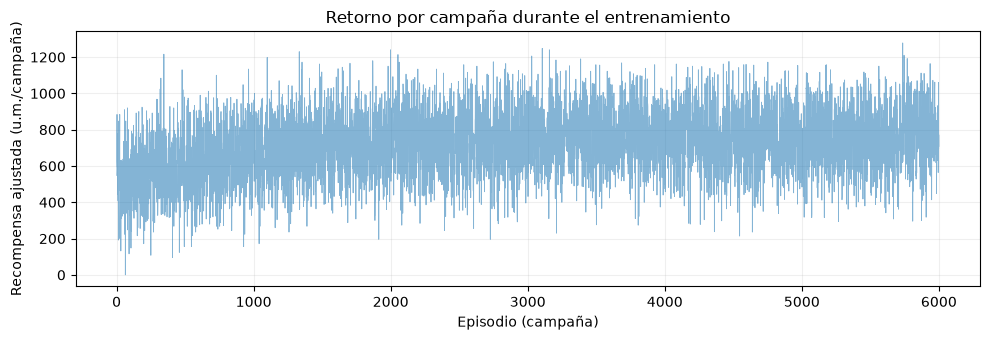

**Interpretación:** con la penalización didáctica, las primeras 500 campañas promedian 572.38 u.m. y las últimas 500, 762.20 u.m. La variación individual refleja compradores y respuestas estocásticas; la comparación final se hará sin exploración.

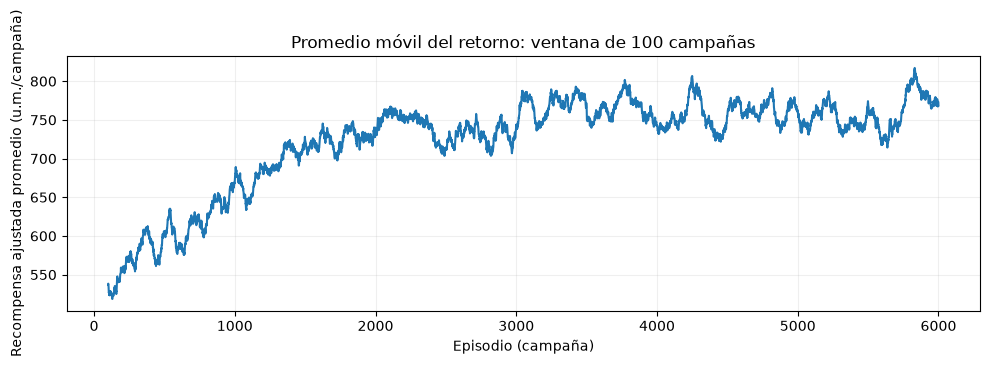

**Interpretación:** cada punto resume 100 campañas y reduce el ruido. Revisamos tendencia y oscilaciones, sin asumir que una curva más estable garantiza una política óptima.

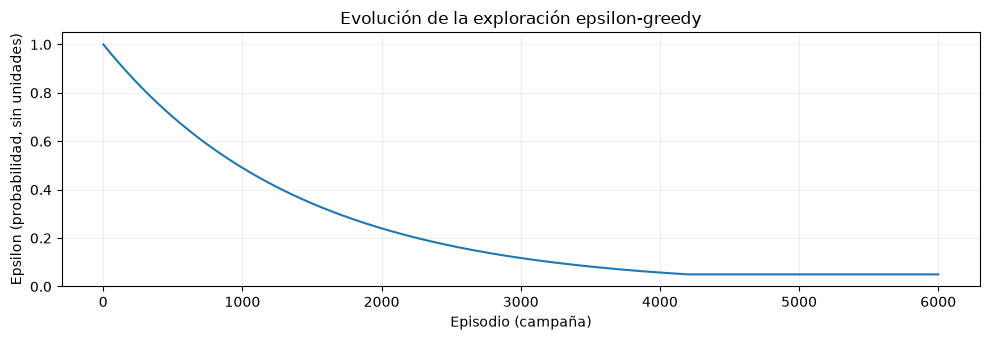

**Interpretación:** epsilon baja de 1.00 a 0.05. Al final aproximadamente el 5% de las decisiones siguen probando acciones; la evaluación usará epsilon=0.

In [17]:
def save_figure(fig, filename):
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=140, bbox_inches="tight")
    plt.show()


fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(training_history["episode"], training_history["return"], alpha=0.55, linewidth=0.6)
ax.set(title="Retorno por campaña durante el entrenamiento", xlabel="Episodio (campaña)",
       ylabel="Recompensa ajustada (u.m./campaña)")
ax.grid(alpha=0.2)
save_figure(fig, "01_retorno_entrenamiento.png")
first_return = training_history["return"].head(500).mean()
last_return = training_history["return"].tail(500).mean()
display(Markdown(f"**Interpretación:** con la penalización didáctica, las primeras 500 campañas promedian {first_return:.2f} u.m. y las últimas 500, {last_return:.2f} u.m. La variación individual refleja compradores y respuestas estocásticas; la comparación final se hará sin exploración."))

fig, ax = plt.subplots(figsize=(10, 3.5))
rolling_return = training_history["return"].rolling(100, min_periods=100).mean()
ax.plot(training_history["episode"], rolling_return)
ax.set(title="Promedio móvil del retorno: ventana de 100 campañas", xlabel="Episodio (campaña)",
       ylabel="Recompensa ajustada promedio (u.m./campaña)")
ax.grid(alpha=0.2)
save_figure(fig, "02_promedio_movil.png")
display(Markdown("**Interpretación:** cada punto resume 100 campañas y reduce el ruido. Revisamos tendencia y oscilaciones, sin asumir que una curva más estable garantiza una política óptima."))

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(training_history["episode"], training_history["epsilon"])
ax.set(title="Evolución de la exploración epsilon-greedy", xlabel="Episodio (campaña)",
       ylabel="Epsilon (probabilidad, sin unidades)", ylim=(0, 1.05))
ax.grid(alpha=0.2)
save_figure(fig, "03_epsilon.png")
display(Markdown(f"**Interpretación:** epsilon baja de {training_history['epsilon'].iloc[0]:.2f} a {training_history['epsilon'].iloc[-1]:.2f}. Al final aproximadamente el 5% de las decisiones siguen probando acciones; la evaluación usará epsilon=0."))

# 15. Evaluación en campañas nuevas

Evaluamos **500 campañas por política**, con semillas 50000–50499, distintas de las 1000–6999 de entrenamiento. Cada política recibe los mismos clientes, agenda y canales por semilla. El selector tiene un generador separado del entorno; `BuyerAgent.react()` consume un sorteo de compra por contacto, por lo que las políticas comparten también los sorteos iniciales. Las compras y estados internos posteriores pueden diferir por las acciones ejecutadas.

La política Q-learning actúa **codiciosamente: epsilon=0**, sólo consulta Q y nunca llama a `update_q`. Comprobamos que ni Q ni las visitas cambien. Para decidir si supera a otra política calculamos también la diferencia de retorno por campaña y su intervalo aproximado del 95%. El intervalo describe incertidumbre por las campañas simuladas; no cubre toda la variabilidad de entrenar de nuevo.


In [18]:
def table_policy(policy_array):
    return lambda state, rng=None: SELLER_ACTIONS[policy_array[STATE_TO_INDEX[state]]]


def greedy_policy_indices(Q_values):
    policy = np.full(N_STATES, -1, dtype=int)
    for s, state in enumerate(STATES):
        valid = valid_action_indices(state)
        if len(valid):
            policy[s] = int(valid[np.argmax(Q_values[s, valid])])
    return policy


q_policy = greedy_policy_indices(Q)


def evaluate_seller(policy_fn, episodes=500, seed=50000, policy_name="Política"):
    evaluation_env = MesaSellerEnv(prediction_cache=prediction_cache)
    rows = []
    rng = np.random.default_rng(98765)
    for episode in range(episodes):
        state = evaluation_env.reset(seed=seed + episode)
        total_reward = income = cost = penalty = 0.0
        purchases = 0
        action_counts = Counter()
        while True:
            action = policy_fn(state, rng)
            state, reward, done, info = evaluation_env.step(action)
            total_reward += reward
            income += info["income"]
            cost += info["action_cost"]
            penalty += info["opportunity_penalty"]
            purchases += int(info["purchased"])
            action_counts[action] += 1
            if done:
                break
        rows.append({"policy": policy_name, "episode": episode + 1, "campaign_seed": seed + episode,
                     "return": total_reward, "sales": purchases, "income": income,
                     "cost": cost, "opportunity_penalty": penalty, "cash_return": income - cost,
                     "budget_used": evaluation_env.initial_budget - evaluation_env.budget_remaining,
                     "budget_used_pct": 100 * (evaluation_env.initial_budget - evaluation_env.budget_remaining) / evaluation_env.initial_budget,
                     "interactions": evaluation_env.episode_step,
                     "termination_reason": info["termination_reason"],
                     **{f"n_{a}": action_counts[a] for a in SELLER_ACTIONS}})
    return pd.DataFrame(rows)


def summarize_evaluation(df):
    return df.groupby("policy", sort=False).agg(
        retorno_promedio=("return", "mean"), retorno_std=("return", "std"),
        ventas_promedio=("sales", "mean"), ingreso_promedio=("income", "mean"),
        costo_promedio=("cost", "mean"), penalizacion_promedio=("opportunity_penalty", "mean"),
        retorno_contable_promedio=("cash_return", "mean"), presupuesto_usado=("budget_used", "mean"),
        presupuesto_usado_pct=("budget_used_pct", "mean"),
        interacciones_promedio=("interactions", "mean"), campanas=("episode", "count"))


def paired_difference(left_df, right_df):
    pairs = left_df[["campaign_seed", "return"]].merge(
        right_df[["campaign_seed", "return"]], on="campaign_seed", suffixes=("_left", "_right"),
        validate="one_to_one")
    delta = pairs["return_left"] - pairs["return_right"]
    margin = 1.96 * delta.std(ddof=1) / np.sqrt(len(delta))
    return {"diferencia_promedio": float(delta.mean()),
            "ic95_inferior": float(delta.mean() - margin),
            "ic95_superior": float(delta.mean() + margin), "campanas": len(delta)}


baseline_policies = {
    "Sin intervención": no_action_policy,
    "Aleatoria": random_policy,
    "Heurística observable": observable_heuristic_policy,
    "Q-learning": table_policy(q_policy),
}


In [19]:
Q_before_evaluation = Q.copy()
visits_before_evaluation = state_action_visits.copy()
evaluation_frames = {
    name: evaluate_seller(policy, policy_name=name)
    for name, policy in baseline_policies.items()
}
evaluation_df = pd.concat(evaluation_frames.values(), ignore_index=True)
summary = summarize_evaluation(evaluation_df)
assert np.array_equal(Q, Q_before_evaluation)
assert np.array_equal(state_action_visits, visits_before_evaluation)
assert set(training_history["campaign_seed"]).isdisjoint(evaluation_df["campaign_seed"])
assert np.allclose(evaluation_df["return"], evaluation_df["income"] - evaluation_df["cost"] - evaluation_df["opportunity_penalty"])
assert np.allclose(evaluation_df["cash_return"], evaluation_df["income"] - evaluation_df["cost"])
assert np.allclose(evaluation_df["return"], evaluation_df["cash_return"] - evaluation_df["opportunity_penalty"])
assert np.allclose(evaluation_df["cost"], evaluation_df["budget_used"])
display(summary.round(2))
comparisons_df = pd.DataFrame([
    {"comparacion": f"Q-learning menos {other}",
     **paired_difference(evaluation_frames["Q-learning"], evaluation_frames[other])}
    for other in ["Aleatoria", "Heurística observable", "Sin intervención"]
])
display(comparisons_df.round(2))


c:\Users\GJLG\Repositorios\Inteligencia artificial avanzada\Inteligencia-artificial-avanzada\.venv\Lib\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


,retorno_promedio,retorno_std,ventas_promedio,ingreso_promedio,costo_promedio,penalizacion_promedio,retorno_contable_promedio,presupuesto_usado,presupuesto_usado_pct,interacciones_promedio,campanas
policy,,,,,,,,,,,
Sin intervención,757.60,181.81,23.80,952.00,0.00,194.40,952.00,0.00,0.00,40.00,500
Aleatoria,543.50,168.34,18.34,682.58,99.84,39.24,582.74,99.84,99.84,29.97,500
Heurística observable,757.35,179.73,23.62,924.58,56.88,110.35,867.70,56.88,56.88,39.92,500
Q-learning,787.79,167.21,24.30,939.50,83.34,68.38,856.16,83.34,83.34,40.00,500


,comparacion,diferencia_promedio,ic95_inferior,ic95_superior,campanas
0,Q-learning menos Aleatoria,244.29,230.72,257.86,500
1,Q-learning menos Heurística observable,30.44,21.48,39.40,500
2,Q-learning menos Sin intervención,30.19,18.68,41.69,500


### Comparación de políticas, frecuencia de acciones y distribución de retornos

Las barras comparan la **recompensa ajustada** en unidades monetarias equivalentes por campaña: ingresos menos costos reales menos la penalización didáctica. El resumen también muestra por separado el retorno contable sin penalización. La tabla anterior incluye desviación estándar; las barras siguientes muestran intervalos aproximados del 95% de la **media**, no la dispersión de campañas individuales.

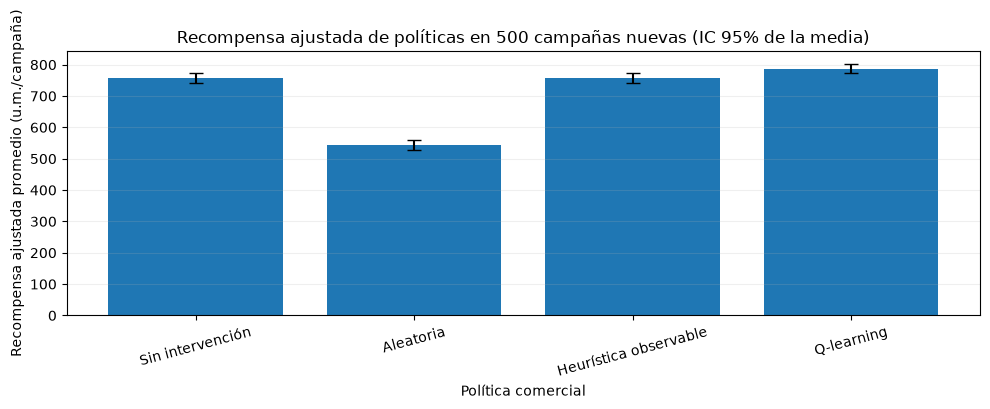

**Interpretación:** con la penalización didáctica, la mayor media corresponde a **Q-learning**, con 787.79 u.m. por campaña. Para valorar una diferencia pequeña usamos la comparación emparejada de la tabla; una media mayor no basta si su intervalo incluye cero.

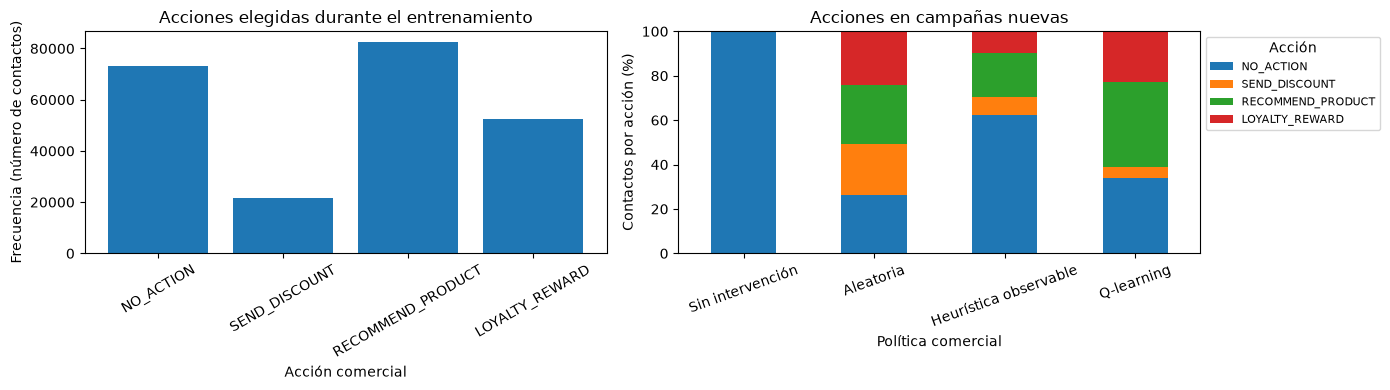

**Interpretación:** se probaron las cuatro acciones durante el entrenamiento. En evaluación Q-learning utiliza más **RECOMMEND_PRODUCT** (38.4% de contactos). Elegir una acción frecuentemente no prueba que sea conveniente en todos los estados.

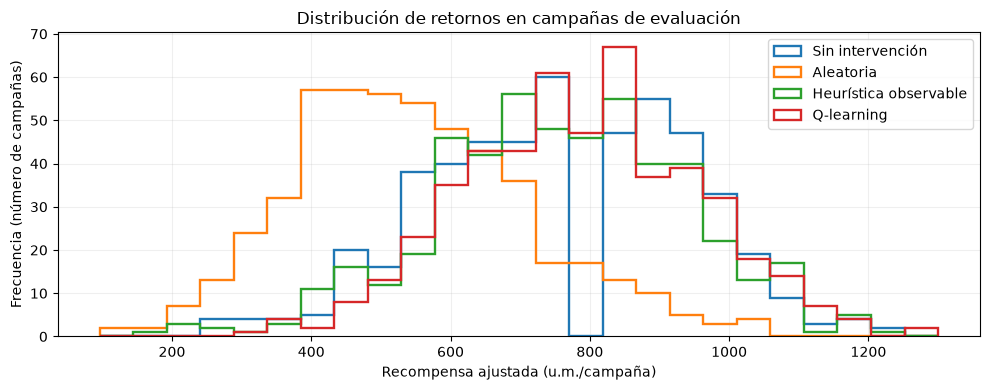

**Interpretación:** una distribución desplazada hacia la derecha representa mayores retornos; su anchura muestra variabilidad. Hay campañas difíciles para todas las políticas porque los perfiles y la disponibilidad de dinero de los compradores varían.

In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
mean_ci = 1.96 * summary["retorno_std"] / np.sqrt(summary["campanas"])
ax.bar(summary.index, summary["retorno_promedio"], yerr=mean_ci, capsize=5)
ax.set(title="Recompensa ajustada de políticas en 500 campañas nuevas (IC 95% de la media)",
       xlabel="Política comercial", ylabel="Recompensa ajustada promedio (u.m./campaña)")
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.2)
save_figure(fig, "04_comparacion_politicas.png")
best_policy_name = summary["retorno_promedio"].idxmax()
display(Markdown(f"**Interpretación:** con la penalización didáctica, la mayor media corresponde a **{best_policy_name}**, con {summary.loc[best_policy_name, 'retorno_promedio']:.2f} u.m. por campaña. Para valorar una diferencia pequeña usamos la comparación emparejada de la tabla; una media mayor no basta si su intervalo incluye cero."))

training_action_counts = experience_df["action"].value_counts().reindex(SELLER_ACTIONS, fill_value=0)
action_counts_eval = evaluation_df.groupby("policy", sort=False)[[f"n_{a}" for a in SELLER_ACTIONS]].sum()
action_percent_eval = action_counts_eval.div(action_counts_eval.sum(axis=1), axis=0) * 100
action_percent_eval.columns = SELLER_ACTIONS
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(SELLER_ACTIONS, training_action_counts)
axes[0].set(title="Acciones elegidas durante el entrenamiento", xlabel="Acción comercial",
            ylabel="Frecuencia (número de contactos)")
axes[0].tick_params(axis="x", rotation=30)
action_percent_eval.plot.bar(stacked=True, ax=axes[1])
axes[1].set(title="Acciones en campañas nuevas", xlabel="Política comercial",
            ylabel="Contactos por acción (%)", ylim=(0, 100))
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="Acción", fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))
save_figure(fig, "05_frecuencia_acciones.png")
q_action_percent = action_percent_eval.loc["Q-learning"]
dominant_action = q_action_percent.idxmax()
display(Markdown(f"**Interpretación:** se probaron las cuatro acciones durante el entrenamiento. En evaluación Q-learning utiliza más **{dominant_action}** ({q_action_percent.max():.1f}% de contactos). Elegir una acción frecuentemente no prueba que sea conveniente en todos los estados."))

fig, ax = plt.subplots(figsize=(10, 4))
bins = np.linspace(evaluation_df["return"].min(), evaluation_df["return"].max(), 26)
for name, frame in evaluation_frames.items():
    ax.hist(frame["return"], bins=bins, histtype="step", linewidth=1.7, label=name)
ax.set(title="Distribución de retornos en campañas de evaluación", xlabel="Recompensa ajustada (u.m./campaña)",
       ylabel="Frecuencia (número de campañas)")
ax.legend()
ax.grid(alpha=0.2)
save_figure(fig, "06_distribucion_retornos.png")
display(Markdown("**Interpretación:** una distribución desplazada hacia la derecha representa mayores retornos; su anchura muestra variabilidad. Hay campañas difíciles para todas las políticas porque los perfiles y la disponibilidad de dinero de los compradores varían."))

# 16. Inspección de la política aprendida

Extraemos $\pi(s)=\arg\max_{a\text{ asequible}}Q(s,a)$. Cada fila muestra el estado, la acción codiciosa, los valores Q y cuántas veces se probó cada acción. **Las visitas importan:** un valor Q calculado con muy pocas muestras no es una conclusión sólida sobre ese estado. Los estados nunca visitados mantienen ceros y seleccionan NO_ACTION por desempate.

La comparación por presupuesto mantiene fijos bucket, canal y respuesta previa. Los cambios de acción en esa tabla describen la política aprendida; no deben interpretarse como una ley general del comportamiento humano. Las combinaciones imposibles del proxy se separan de las que sí podrían aparecer pero no fueron exploradas.


In [21]:
policy_rows = []
for s_idx, state in enumerate(STATES):
    is_terminal = state == TERMINAL_STATE
    structurally_possible = (not is_terminal and
        not (state[0] == "HIGH" and state[1] not in ["Search", "Email"]))
    policy_rows.append({
        "bucket_cliente": state[0], "fuente_trafico": state[1],
        "respuesta_previa": state[2], "presupuesto_restante": state[3],
        "accion": SELLER_ACTIONS[q_policy[s_idx]] if not is_terminal else "TERMINAL",
        "visitas_estado": int(state_action_visits[s_idx].sum()),
        "combinacion_posible_proxy": structurally_possible,
        **{f"Q_{a}": float(Q[s_idx, j]) for j, a in enumerate(SELLER_ACTIONS)},
        **{f"visitas_{a}": int(state_action_visits[s_idx, j]) for j, a in enumerate(SELLER_ACTIONS)},
    })
policy_df = pd.DataFrame(policy_rows)
decision_policy_df = policy_df[policy_df["accion"] != "TERMINAL"].copy()
possible_policy_df = decision_policy_df[decision_policy_df["combinacion_posible_proxy"]]
visited_states = int((decision_policy_df["visitas_estado"] > 0).sum())
unvisited_possible = int((possible_policy_df["visitas_estado"] == 0).sum())
rare_possible = int(possible_policy_df["visitas_estado"].between(1, 9).sum())
valid_pair_mask = np.zeros_like(state_action_visits, dtype=bool)
for s_idx, state in enumerate(STATES):
    valid_pair_mask[s_idx, valid_action_indices(state)] = True
possible_pair_mask = valid_pair_mask & policy_df["combinacion_posible_proxy"].to_numpy()[:, None]
untried_possible_pairs = int(((state_action_visits == 0) & possible_pair_mask).sum())
coverage_df = pd.DataFrame([{
    "estados_decision_teoricos": len(decision_policy_df),
    "estados_posibles_segun_proxy": len(possible_policy_df),
    "estados_visitados": visited_states,
    "posibles_sin_visitas": unvisited_possible,
    "posibles_con_1_a_9_visitas": rare_possible,
    "pares_posibles_asequibles_sin_explorar": untried_possible_pairs,
}])
display(coverage_df)
examples_df = (decision_policy_df[decision_policy_df["visitas_estado"] >= 10]
               .sort_values("visitas_estado", ascending=False)
               .groupby("accion", sort=False).head(3))
display(examples_df[["bucket_cliente", "fuente_trafico", "respuesta_previa",
                     "presupuesto_restante", "accion", "visitas_estado"]])
for action in SELLER_ACTIONS:
    chosen = examples_df[examples_df["accion"] == action]
    if chosen.empty:
        text = f"**{action}:** no apareció en los ejemplos con al menos 10 visitas; no forzamos una decisión para que salgan las cuatro acciones."
    else:
        row = chosen.iloc[0]
        text = (f"**{action}:** la política la elige, por ejemplo, en "
                f"({row['bucket_cliente']}, {row['fuente_trafico']}, {row['respuesta_previa']}, "
                f"{row['presupuesto_restante']} u.m.), con {row['visitas_estado']} visitas. "
                "Esto refleja el mayor Q entre acciones asequibles en ese estado.")
    display(Markdown(text))
budget_policy_df = decision_policy_df[
    (decision_policy_df["bucket_cliente"] == "MEDIUM") &
    (decision_policy_df["respuesta_previa"] == "NO_PURCHASE") &
    decision_policy_df["presupuesto_restante"].isin([2, 8, 20, 50, 100])
][["fuente_trafico", "presupuesto_restante", "accion", "visitas_estado"]]
display(budget_policy_df)
display(Markdown(f"**Cobertura:** {visited_states} de {len(decision_policy_df)} estados teóricos tuvieron visitas. De los {len(possible_policy_df)} compatibles con el proxy, {unvisited_possible} nunca aparecieron y {rare_possible} tuvieron entre 1 y 9 visitas. Existen {untried_possible_pairs} pares estado-acción posibles y asequibles sin probar. Parte de los ceros es estructural: HIGH no aparece en tres de los cinco canales."))

,estados_decision_teoricos,estados_posibles_segun_proxy,estados_visitados,posibles_sin_visitas,posibles_con_1_a_9_visitas,pares_posibles_asequibles_sin_explorar
0,2250,1800,1705,95,320,1470


,bucket_cliente,fuente_trafico,respuesta_previa,presupuesto_restante,accion,visitas_estado
1099,MEDIUM,Email,NONE,100,NO_ACTION,2561
799,MEDIUM,Search,NONE,100,NO_ACTION,2541
499,LOW,Display,NONE,100,NO_ACTION,2122
1123,MEDIUM,Email,PURCHASE,48,RECOMMEND_PRODUCT,783
849,MEDIUM,Search,PURCHASE,100,LOYALTY_REWARD,643
1118,MEDIUM,Email,PURCHASE,38,LOYALTY_REWARD,607
673,LOW,Facebook,PURCHASE,48,RECOMMEND_PRODUCT,585
809,MEDIUM,Search,PURCHASE,20,RECOMMEND_PRODUCT,564
818,MEDIUM,Search,PURCHASE,38,LOYALTY_REWARD,559
829,MEDIUM,Search,PURCHASE,60,SEND_DISCOUNT,557


**NO_ACTION:** la política la elige, por ejemplo, en (MEDIUM, Email, NONE, 100 u.m.), con 2561 visitas. Esto refleja el mayor Q entre acciones asequibles en ese estado.

**SEND_DISCOUNT:** la política la elige, por ejemplo, en (MEDIUM, Search, PURCHASE, 60 u.m.), con 557 visitas. Esto refleja el mayor Q entre acciones asequibles en ese estado.

**RECOMMEND_PRODUCT:** la política la elige, por ejemplo, en (MEDIUM, Email, PURCHASE, 48 u.m.), con 783 visitas. Esto refleja el mayor Q entre acciones asequibles en ese estado.

**LOYALTY_REWARD:** la política la elige, por ejemplo, en (MEDIUM, Search, PURCHASE, 100 u.m.), con 643 visitas. Esto refleja el mayor Q entre acciones asequibles en ese estado.

,fuente_trafico,presupuesto_restante,accion,visitas_estado
850,Search,2,NO_ACTION,490
853,Search,8,RECOMMEND_PRODUCT,113
859,Search,20,NO_ACTION,370
874,Search,50,NO_ACTION,255
899,Search,100,NO_ACTION,488
1000,Organic,2,NO_ACTION,181
1003,Organic,8,LOYALTY_REWARD,33
1009,Organic,20,LOYALTY_REWARD,116
1024,Organic,50,SEND_DISCOUNT,105
1049,Organic,100,SEND_DISCOUNT,152


**Cobertura:** 1705 de 2250 estados teóricos tuvieron visitas. De los 1800 compatibles con el proxy, 95 nunca aparecieron y 320 tuvieron entre 1 y 9 visitas. Existen 1470 pares estado-acción posibles y asequibles sin probar. Parte de los ceros es estructural: HIGH no aparece en tres de los cinco canales.

### Cómo interpretar descuentos, recomendaciones y presupuesto

Los ejemplos anteriores identifican estados donde Q-learning prefiere cada acción: se consulta una estimación de retorno, no la etiqueta del cliente. **Un descuento puede elevar la probabilidad de compra y aun reducir el retorno**, porque baja el precio y cuesta 8 u.m. Recomendar mantiene el precio y cuesta 2 u.m. NO_ACTION puede ser conveniente para conservar presupuesto o cuando el ingreso adicional esperado no compensa el costo, pero si no hay compra recibe la penalización didáctica de 12 u.m. Esta sanción no representa dinero gastado ni prueba que se perdió una venta.

Con sólo 2 u.m. quedan disponibles NO_ACTION y RECOMMEND_PRODUCT; los descuentos requieren al menos 8 u.m. y los premios de lealtad al menos 4 u.m. La restricción se aplica al seleccionar, al extraer la política y al calcular el valor del siguiente estado. Además de ese efecto obligatorio, Q puede aprender el valor de reservar dinero para contactos posteriores. No hay garantía de que lo haya aprendido correctamente en estados poco visitados.


## Experimento: cambiar el factor de descuento

Comparamos **gamma=0.95** con **gamma=0.0**, conservando alpha, epsilon, costos, estados, cantidad de episodios, semillas iniciales y presupuesto. Con gamma=0 el agente aprende el resultado inmediato de cada contacto; con 0.95 propaga parte del retorno futuro. El simulador tiene compradores persistentes, así que las acciones pueden tener consecuencias posteriores; sin embargo, el estado resumido mezcla situaciones distintas.

La evaluación utiliza las mismas 500 campañas nuevas y ninguna tabla se actualiza. Se reportan medias, dispersión y diferencia emparejada. **No escogemos la configuración definitiva mirando estas campañas:** la política principal sigue siendo la base prefijada, y el cambio se presenta como análisis. Un entrenamiento por configuración no permite atribuir todas las diferencias únicamente a gamma; faltaría repetir el entrenamiento con más inicializaciones.

c:\Users\GJLG\Repositorios\Inteligencia artificial avanzada\Inteligencia-artificial-avanzada\.venv\Lib\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


Episodios 1000/6000 | epsilon=0.490
Episodios 2000/6000 | epsilon=0.240
Episodios 3000/6000 | epsilon=0.118
Episodios 4000/6000 | epsilon=0.058
Episodios 5000/6000 | epsilon=0.050
Episodios 6000/6000 | epsilon=0.050


,retorno_promedio,retorno_std,ventas_promedio,ingreso_promedio,costo_promedio,penalizacion_promedio,retorno_contable_promedio,presupuesto_usado,presupuesto_usado_pct,interacciones_promedio,campanas
policy,,,,,,,,,,,
Q-learning gamma=0.95,787.79,167.21,24.30,939.50,83.34,68.38,856.16,83.34,83.34,40.0,500
Q-learning gamma=0.0,812.02,185.84,23.61,923.14,93.26,17.86,829.88,93.26,93.26,39.5,500


,comparacion,diferencia_promedio,ic95_inferior,ic95_superior,campanas
0,gamma=0.0 menos gamma=0.95,24.24,14.51,33.96,500


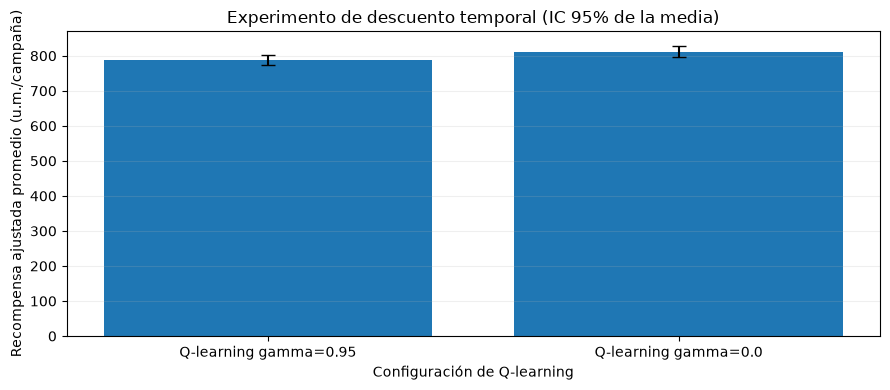

**Interpretación:** El cambio a gamma=0.0 mejoró el retorno en estas campañas. La diferencia media (0.0 menos 0.95) es 24.24 u.m.; IC aproximado 95% [14.51, 33.96]. Con gamma=0 el objetivo no propaga valores futuros: aprende ingresos netos inmediatos y puede reducir el ruido producido por estados parcialmente observables. A cambio, no valora conservar presupuesto ni mejorar la relación para contactos posteriores. Gamma=0.95 considera esos efectos mediante Q, pero sus estimaciones dependen de la cobertura, del horizonte omitido y de los valores futuros aprendidos. Estos mecanismos son explicaciones posibles; el experimento por sí solo no identifica cuál causó la diferencia.

In [22]:
EXPERIMENT_GAMMA = 0.0
Q_experiment, visits_experiment, experiment_experience_df, experiment_history = train_q_learning(
    gamma=EXPERIMENT_GAMMA)
experiment_policy = greedy_policy_indices(Q_experiment)
Q_experiment_frozen = Q_experiment.copy()
experiment_eval_df = evaluate_seller(table_policy(experiment_policy), policy_name="Q-learning gamma=0.0")
assert np.array_equal(Q_experiment, Q_experiment_frozen)
experiment_summary = pd.concat([
    evaluation_frames["Q-learning"].assign(policy="Q-learning gamma=0.95"),
    experiment_eval_df,
], ignore_index=True)
experiment_summary = summarize_evaluation(experiment_summary)
experiment_difference = paired_difference(experiment_eval_df, evaluation_frames["Q-learning"])
display(experiment_summary.round(2))
display(pd.DataFrame([{"comparacion": "gamma=0.0 menos gamma=0.95", **experiment_difference}]).round(2))
fig, ax = plt.subplots(figsize=(9, 4))
experiment_ci = 1.96 * experiment_summary["retorno_std"] / np.sqrt(experiment_summary["campanas"])
ax.bar(experiment_summary.index, experiment_summary["retorno_promedio"], yerr=experiment_ci, capsize=5)
ax.set(title="Experimento de descuento temporal (IC 95% de la media)",
       xlabel="Configuración de Q-learning", ylabel="Recompensa ajustada promedio (u.m./campaña)")
ax.grid(axis="y", alpha=0.2)
save_figure(fig, "07_experimento_gamma.png")
if experiment_difference["ic95_inferior"] > 0:
    experiment_verdict = "El cambio a gamma=0.0 mejoró el retorno en estas campañas."
elif experiment_difference["ic95_superior"] < 0:
    experiment_verdict = "El cambio a gamma=0.0 redujo el retorno en estas campañas."
else:
    experiment_verdict = "El intervalo incluye cero: estas campañas no muestran una diferencia concluyente."
experiment_explanation = (
    "Con gamma=0 el objetivo no propaga valores futuros: aprende ingresos netos inmediatos y puede reducir "
    "el ruido producido por estados parcialmente observables. A cambio, no valora conservar presupuesto "
    "ni mejorar la relación para contactos posteriores. Gamma=0.95 considera esos efectos mediante Q, "
    "pero sus estimaciones dependen de la cobertura, del horizonte omitido y de los valores futuros aprendidos. "
    "Estos mecanismos son explicaciones posibles; el experimento por sí solo no identifica cuál causó la diferencia.")
display(Markdown(f"**Interpretación:** {experiment_verdict} La diferencia media (0.0 menos 0.95) es {experiment_difference['diferencia_promedio']:.2f} u.m.; IC aproximado 95% [{experiment_difference['ic95_inferior']:.2f}, {experiment_difference['ic95_superior']:.2f}]. {experiment_explanation}"))

# 17. Discusión y conclusiones

Las respuestas siguientes se construyen con las tablas ejecutadas. **No suponemos que Q-learning gana:** se distingue la media observada de la incertidumbre y se consideran las limitaciones del simulador. Conserva estas cifras al explicar la entrega; si cambias parámetros, vuelve a ejecutar todo.


In [23]:
random_comparison = paired_difference(evaluation_frames["Q-learning"], evaluation_frames["Aleatoria"])
if random_comparison["ic95_inferior"] > 0:
    random_verdict = "Sí, en estas campañas simuladas la diferencia es positiva y el intervalo no incluye cero."
elif random_comparison["ic95_superior"] < 0:
    random_verdict = "No: en estas campañas simuladas la política aleatoria obtuvo un retorno mayor."
else:
    random_verdict = "La diferencia no es concluyente: el intervalo aproximado incluye cero."
action_description = "; ".join(f"{a}: {q_action_percent[a]:.1f}%" for a in SELLER_ACTIONS)
q_mean = summary.loc["Q-learning", "retorno_promedio"]
random_mean = summary.loc["Aleatoria", "retorno_promedio"]
none_mean = summary.loc["Sin intervención", "retorno_promedio"]
discussion_md = f"""
1. **¿La política aprendida supera a la aleatoria?** {random_verdict} Q-learning promedia {q_mean:.2f} u.m. y la aleatoria {random_mean:.2f} u.m.; diferencia {random_comparison['diferencia_promedio']:.2f} u.m., IC 95% [{random_comparison['ic95_inferior']:.2f}, {random_comparison['ic95_superior']:.2f}]. Sin intervención promedia {none_mean:.2f} u.m. de recompensa ajustada; consulta también el retorno contable para no confundir esta penalización ficticia con dinero gastado. Son conclusiones sobre estas campañas y esta tabla entrenada.

2. **¿Qué acciones usa más?** {action_description}. La más frecuente es {dominant_action}. Los ejemplos de la sección 16 muestran estados concretos y sus visitas. Si una acción es rara, eso no demuestra que nunca sea útil: puede faltar exploración o quedar oculta la diferencia entre compradores.

3. **¿Qué efecto tiene el presupuesto?** Limita las acciones asequibles; con 2 u.m. se excluyen descuento y lealtad. Gastar antes también reduce oportunidades posteriores y puede terminar la campaña. La tabla por presupuesto muestra decisiones manteniendo otras variables fijas; se debe revisar su número de visitas antes de confiar en ellas.

4. **¿El estado conserva suficiente información?** Conserva canal, señal del perfil, respuesta previa y dinero disponible; permite una aproximación tabular útil. No es plenamente Markov: omite tiempo restante, historial completo, finanzas reales y relación interna. Distintos clientes y campañas pueden compartir un estado y responder distinto. El proxy no es una probabilidad calibrada y agruparlo pierde información.

5. **¿Hay estados casi nunca visitados?** Sí: {unvisited_possible} combinaciones compatibles con el proxy tienen cero visitas y {rare_possible} tienen entre 1 y 9. Hay además combinaciones imposibles del proxy, como HIGH en Organic, Display y Facebook. {untried_possible_pairs} pares posibles y asequibles no fueron explorados. En estados sin visitas, Q=0 y el desempate elige NO_ACTION; esa decisión es una salida por defecto.

6. **¿Cómo afecta la exploración?** Epsilon empieza en 1.0, baja exponencialmente hasta 0.05 durante el primer 70% del entrenamiento y después se mantiene. Permite probar las cuatro acciones y descubrir sus resultados, pero también causa gastos y malas decisiones mientras se aprende. Reducirlo demasiado rápido puede dejar alternativas sin probar; mantenerlo alto impide aprovechar lo aprendido. La curva y los contadores muestran esta relación; aquí no se realizó un experimento causal sobre epsilon.

7. **¿La recompensa representa el objetivo comercial?** Combina ingreso efectivamente cobrado, costo real de contacto y una penalización sintética de 12 u.m. si NO_ACTION termina sin compra. El **retorno contable** (ingreso menos costo) se reporta aparte: la penalización guía el aprendizaje, pero no es una pérdida comprobada ni debe presentarse como dinero real. La evaluación ajustada responde al objetivo definido por el equipo; no mide utilidad empresarial completa: faltan mercancía, envío, devolución y valor del cliente a largo plazo. La evaluación suma recompensas sin descuento; gamma=0.95 aproxima un objetivo con preferencia temporal. El experimento compara esa elección con gamma=0.

8. **¿Qué podría producir una política poco realista?** Coeficientes sintéticos fuertes, arquetipos fijos, precios únicos, canales elegidos uniformemente, seis compradores por campaña, salarios artificiales y ausencia de competencia. NO_ACTION puede producir compras espontáneas a costo cero; penalizar los contactos sin compra contrarresta ese supuesto, pero también introduce una preferencia inventada por intervenir. Terminar al agotar el presupuesto impide contactos gratuitos posteriores y puede favorecer reservar dinero. Los contactos son programados por el adaptador, sin movimiento espacial. Además, el perfil incluye edad y país con supuestos ficticios, que no deben generalizarse a personas reales.

9. **¿Qué cambiaríamos en un sistema real?** Validar perfiles y costos con datos consentidos; evitar segmentación injusta; medir margen, devoluciones, bajas y fatiga; incluir tiempo restante e historial observable; incorporar inventario y restricciones de contacto; estimar incertidumbre y deriva. Evaluar primero fuera de producción con datos históricos adecuados y después mediante pruebas controladas con supervisión humana. Los resultados simulados no justifican desplegar esta política directamente.

**Conclusión del experimento:** {experiment_verdict} Diferencia media: {experiment_difference['diferencia_promedio']:.2f} u.m. {experiment_explanation} Se usó una inicialización por configuración; conviene repetir para estimar la variabilidad del entrenamiento.

**Conclusión de la actividad:** se generaron {len(experience_df):,} transiciones del agente principal, se probaron las cuatro acciones, se actualizó Q explícitamente y se evaluó una política codiciosa sin modificarla en 500 campañas nuevas por política. La mejor media observada fue la de {best_policy_name}; la cobertura y la observabilidad parcial limitan cuánto podemos generalizar.
"""
display(Markdown(discussion_md))


1. **¿La política aprendida supera a la aleatoria?** Sí, en estas campañas simuladas la diferencia es positiva y el intervalo no incluye cero. Q-learning promedia 787.79 u.m. y la aleatoria 543.50 u.m.; diferencia 244.29 u.m., IC 95% [230.72, 257.86]. Sin intervención promedia 757.60 u.m. de recompensa ajustada; consulta también el retorno contable para no confundir esta penalización ficticia con dinero gastado. Son conclusiones sobre estas campañas y esta tabla entrenada.

2. **¿Qué acciones usa más?** NO_ACTION: 33.8%; SEND_DISCOUNT: 5.1%; RECOMMEND_PRODUCT: 38.4%; LOYALTY_REWARD: 22.6%. La más frecuente es RECOMMEND_PRODUCT. Los ejemplos de la sección 16 muestran estados concretos y sus visitas. Si una acción es rara, eso no demuestra que nunca sea útil: puede faltar exploración o quedar oculta la diferencia entre compradores.

3. **¿Qué efecto tiene el presupuesto?** Limita las acciones asequibles; con 2 u.m. se excluyen descuento y lealtad. Gastar antes también reduce oportunidades posteriores y puede terminar la campaña. La tabla por presupuesto muestra decisiones manteniendo otras variables fijas; se debe revisar su número de visitas antes de confiar en ellas.

4. **¿El estado conserva suficiente información?** Conserva canal, señal del perfil, respuesta previa y dinero disponible; permite una aproximación tabular útil. No es plenamente Markov: omite tiempo restante, historial completo, finanzas reales y relación interna. Distintos clientes y campañas pueden compartir un estado y responder distinto. El proxy no es una probabilidad calibrada y agruparlo pierde información.

5. **¿Hay estados casi nunca visitados?** Sí: 95 combinaciones compatibles con el proxy tienen cero visitas y 320 tienen entre 1 y 9. Hay además combinaciones imposibles del proxy, como HIGH en Organic, Display y Facebook. 1470 pares posibles y asequibles no fueron explorados. En estados sin visitas, Q=0 y el desempate elige NO_ACTION; esa decisión es una salida por defecto.

6. **¿Cómo afecta la exploración?** Epsilon empieza en 1.0, baja exponencialmente hasta 0.05 durante el primer 70% del entrenamiento y después se mantiene. Permite probar las cuatro acciones y descubrir sus resultados, pero también causa gastos y malas decisiones mientras se aprende. Reducirlo demasiado rápido puede dejar alternativas sin probar; mantenerlo alto impide aprovechar lo aprendido. La curva y los contadores muestran esta relación; aquí no se realizó un experimento causal sobre epsilon.

7. **¿La recompensa representa el objetivo comercial?** Combina ingreso efectivamente cobrado, costo real de contacto y una penalización sintética de 12 u.m. si NO_ACTION termina sin compra. El **retorno contable** (ingreso menos costo) se reporta aparte: la penalización guía el aprendizaje, pero no es una pérdida comprobada ni debe presentarse como dinero real. La evaluación ajustada responde al objetivo definido por el equipo; no mide utilidad empresarial completa: faltan mercancía, envío, devolución y valor del cliente a largo plazo. La evaluación suma recompensas sin descuento; gamma=0.95 aproxima un objetivo con preferencia temporal. El experimento compara esa elección con gamma=0.

8. **¿Qué podría producir una política poco realista?** Coeficientes sintéticos fuertes, arquetipos fijos, precios únicos, canales elegidos uniformemente, seis compradores por campaña, salarios artificiales y ausencia de competencia. NO_ACTION puede producir compras espontáneas a costo cero; penalizar los contactos sin compra contrarresta ese supuesto, pero también introduce una preferencia inventada por intervenir. Terminar al agotar el presupuesto impide contactos gratuitos posteriores y puede favorecer reservar dinero. Los contactos son programados por el adaptador, sin movimiento espacial. Además, el perfil incluye edad y país con supuestos ficticios, que no deben generalizarse a personas reales.

9. **¿Qué cambiaríamos en un sistema real?** Validar perfiles y costos con datos consentidos; evitar segmentación injusta; medir margen, devoluciones, bajas y fatiga; incluir tiempo restante e historial observable; incorporar inventario y restricciones de contacto; estimar incertidumbre y deriva. Evaluar primero fuera de producción con datos históricos adecuados y después mediante pruebas controladas con supervisión humana. Los resultados simulados no justifican desplegar esta política directamente.

**Conclusión del experimento:** El cambio a gamma=0.0 mejoró el retorno en estas campañas. Diferencia media: 24.24 u.m. Con gamma=0 el objetivo no propaga valores futuros: aprende ingresos netos inmediatos y puede reducir el ruido producido por estados parcialmente observables. A cambio, no valora conservar presupuesto ni mejorar la relación para contactos posteriores. Gamma=0.95 considera esos efectos mediante Q, pero sus estimaciones dependen de la cobertura, del horizonte omitido y de los valores futuros aprendidos. Estos mecanismos son explicaciones posibles; el experimento por sí solo no identifica cuál causó la diferencia. Se usó una inicialización por configuración; conviene repetir para estimar la variabilidad del entrenamiento.

**Conclusión de la actividad:** se generaron 230,213 transiciones del agente principal, se probaron las cuatro acciones, se actualizó Q explícitamente y se evaluó una política codiciosa sin modificarla en 500 campañas nuevas por política. La mejor media observada fue la de Q-learning; la cobertura y la observabilidad parcial limitan cuánto podemos generalizar.


# 18. Exportación de la entrega

El código del entorno Mesa y la implementación explícita de Q-learning **están en este mismo notebook**. La siguiente celda guarda los datasets CSV, Q, política, resultados, siete figuras, discusión y README dentro de `resultados_mesa_qlearning`, y prepara un ZIP con esos resultados. No crea módulos de código ni requiere importaciones de archivos externos.

**Qué debes entender al cargar los datos:** las columnas de estado del CSV se guardan como listas JSON. Se recuperan con `tuple(json.loads(texto))`, sin usar `eval`. Los ceros de Q no representan certeza: consulta también las columnas de visitas. El CSV de política incluye una fila terminal con acción TERMINAL, que no se ejecuta. Las columnas `cash_return` y `opportunity_penalty` separan dinero real y penalización didáctica.

En Colab descarga el notebook desde **Archivo → Descargar → Descargar .ipynb** y descarga también `resultados_mesa_qlearning.zip` desde el panel Archivos. El ZIP contiene los resultados; el notebook se entrega por separado.


In [24]:
import zipfile


def export_transitions(df, filename):
    export_df = df.copy()
    for column in ["state", "next_state"]:
        export_df[column] = export_df[column].map(lambda s: json.dumps(s, ensure_ascii=False))
    export_df.to_csv(OUTPUT_DIR / filename, index=False, encoding="utf-8")


export_transitions(experience_df, "transiciones_entrenamiento.csv")
export_transitions(experiment_experience_df, "transiciones_experimento_gamma0.csv")
training_history.to_csv(OUTPUT_DIR / "entrenamiento.csv", index=False)
experiment_history.to_csv(OUTPUT_DIR / "entrenamiento_experimento.csv", index=False)
evaluation_df.to_csv(OUTPUT_DIR / "evaluacion_campanas.csv", index=False)
summary.to_csv(OUTPUT_DIR / "resumen_evaluacion.csv")
comparisons_df.to_csv(OUTPUT_DIR / "comparaciones_emparejadas.csv", index=False)
experiment_eval_df.to_csv(OUTPUT_DIR / "evaluacion_experimento.csv", index=False)
experiment_summary.to_csv(OUTPUT_DIR / "resumen_experimento.csv")
policy_df.to_csv(OUTPUT_DIR / "tabla_q_y_politica.csv", index=False)
coverage_df.to_csv(OUTPUT_DIR / "cobertura.csv", index=False)
examples_df.to_csv(OUTPUT_DIR / "ejemplos_politica.csv", index=False)
budget_policy_df.to_csv(OUTPUT_DIR / "politica_por_presupuesto.csv", index=False)
action_percent_eval.to_csv(OUTPUT_DIR / "frecuencia_acciones_evaluacion_pct.csv")
np.savez_compressed(OUTPUT_DIR / "tabla_q.npz", Q=Q, visits=state_action_visits,
                    states=np.array([json.dumps(s) for s in STATES]),
                    actions=np.array(SELLER_ACTIONS), policy=q_policy)

run_config = {
    "algorithm": "Q-learning tabular explícito",
    "state_fields": ["bucket_cliente", "fuente_trafico", "respuesta_previa", "presupuesto_restante"],
    "n_states": N_STATES, "n_actions": N_ACTIONS,
    "initial_budget": INITIAL_BUDGET, "max_interactions": MAX_INTERACTIONS,
    "n_buyers": N_BUYERS_CAMPAIGN, "base_price": BASE_PRICE,
    "action_contact_costs": ACTION_CONTACT_COST,
    "reward": "ingreso al precio efectivo menos costo del contacto menos 12 si NO_ACTION no compra",
    "missed_opportunity_penalty": MISSED_OPPORTUNITY_PENALTY,
    "episodes_train": EPISODES_TRAIN, "alpha": ALPHA, "gamma": GAMMA,
    "epsilon_initial": EPSILON_INITIAL, "epsilon_min": EPSILON_MIN,
    "epsilon_schedule": "exponencial durante 70%; después constante en el mínimo",
    "train_seeds": [TRAIN_SEED_START, TRAIN_SEED_START + EPISODES_TRAIN - 1],
    "agent_seed": AGENT_SEED, "evaluation_seeds": [50000, 50499],
    "evaluation_epsilon": 0.0, "terminal_state": list(TERMINAL_STATE),
    "versions": {"mesa": mesa.__version__, "numpy": np.__version__, "pandas": pd.__version__},
    "experiment_gamma": EXPERIMENT_GAMMA,
    "experiment_paired_difference": experiment_difference,
}
policy_artifact = {"metadata": run_config, "policy": [
    {"state": list(state),
     "action": SELLER_ACTIONS[q_policy[i]] if state != TERMINAL_STATE else "TERMINAL",
     "state_visits": int(state_action_visits[i].sum())}
    for i, state in enumerate(STATES)]}
(OUTPUT_DIR / "politica_aprendida.json").write_text(
    json.dumps(policy_artifact, ensure_ascii=False, indent=2), encoding="utf-8")
(OUTPUT_DIR / "configuracion_y_resultados.json").write_text(
    json.dumps(run_config, ensure_ascii=False, indent=2), encoding="utf-8")
(OUTPUT_DIR / "discusion_y_conclusiones.md").write_text(discussion_md.strip() + "\n", encoding="utf-8")

readme_text = f"""# Actividad Mesa Commerce: Q-learning

## Ejecución en Google Colab

1. Abre `Mesa_Commerce_Customer_Types_v8_RL_STUDENT (1).ipynb` en Google Colab.
2. Selecciona **Runtime → Run all** (Entorno de ejecución → Ejecutar todas).
3. La primera celda instala Mesa con `%pip install -q mesa`.
4. El notebook entrena {EPISODES_TRAIN} campañas, evalúa 500 campañas nuevas por política y repite el entrenamiento para el experimento gamma=0.0. No necesita GPU, archivos Python externos, credenciales, llaves de API ni servicios GCP.
5. En el panel Archivos descarga `resultados_mesa_qlearning.zip`. Descarga el notebook ejecutado desde Archivo → Descargar → Descargar .ipynb y entrega ambos.

## Ejecución local

Abre el mismo notebook en Jupyter o VS Code con Python y un kernel de Jupyter que tenga NumPy, pandas y Matplotlib. Ejecuta todas las celdas en orden. Mesa se instala desde el notebook. Los resultados se escriben en `resultados_mesa_qlearning` dentro del directorio de trabajo del kernel. Volver a ejecutar regenera los archivos con las mismas semillas.

Versiones registradas: Mesa {mesa.__version__}, NumPy {np.__version__}, pandas {pd.__version__}. El entorno conserva la API de Mesa 3 del notebook base; si una versión futura introduce cambios incompatibles, usa la versión de Mesa registrada en esta ejecución.

## Código y decisiones

Todo el código está dentro del notebook. Las clases SourceAgent, BuyerAgent y CommerceWorld se conservan del profesor. La sección 9 completa el adaptador de campañas; la sección 14 implementa explícitamente epsilon-greedy y la actualización Q, con tratamiento terminal y acciones asequibles. Las rutas opcionales de policy iteration y value iteration quedan como contexto y no son necesarias para esta actividad.

Presupuesto inicial: {INITIAL_BUDGET} u.m.; máximo: {MAX_INTERACTIONS} contactos; compradores: {N_BUYERS_CAMPAIGN}. Estado: bucket observable, canal actual, respuesta previa de ese comprador y presupuesto exacto. Recompensa ajustada: ingreso al precio efectivo menos costo del contacto menos 12 u.m. si NO_ACTION no consigue compra. La penalización es un supuesto didáctico, no una venta perdida demostrada ni un débito del presupuesto. Las columnas `cash_return` y `opportunity_penalty` permiten auditar dinero y objetivo por separado. Los ingresos no reponen presupuesto. El proxy local es una heurística del profesor, no un modelo calibrado.

## Archivos entregados

- `transiciones_entrenamiento.csv`: {len(experience_df):,} transiciones reales del entrenamiento principal con episodio, paso, estado, acción, recompensa, siguiente estado, final, presupuesto, compra, costos y auditoría Q.
- `transiciones_experimento_gamma0.csv`: transiciones del experimento.
- `tabla_q.npz`: Q, visitas, estados, acciones y política. Se carga con `np.load`, sin habilitar pickle.
- `tabla_q_y_politica.csv` y `politica_aprendida.json`: acciones codiciosas y visitas; la fila terminal no es una decisión ejecutable.
- `entrenamiento.csv` y `entrenamiento_experimento.csv`: resultados por episodio y epsilon.
- `evaluacion_campanas.csv` y `resumen_evaluacion.csv`: recompensa ajustada, retorno contable, penalización, desviación estándar, ventas, ingresos, costos, presupuesto e interacciones.
- `comparaciones_emparejadas.csv`: diferencias por campañas idénticas e intervalos aproximados del 95%.
- `evaluacion_experimento.csv` y `resumen_experimento.csv`: comparación gamma=0.0 frente a 0.95.
- `cobertura.csv`, `ejemplos_politica.csv` y `politica_por_presupuesto.csv`: inspección de decisiones y estados poco explorados.
- `frecuencia_acciones_evaluacion_pct.csv`: porcentaje de contactos por acción y política.
- Siete PNG: retorno, promedio móvil, epsilon, políticas, frecuencia de acciones, distribución de retornos y experimento.
- `configuracion_y_resultados.json`: parámetros, semillas, versiones y comparación del experimento.
- `discusion_y_conclusiones.md`: respuestas a las nueve preguntas con cifras de esta ejecución.

Las columnas `state` y `next_state` del CSV contienen listas JSON: usa `tuple(json.loads(texto))` para recuperar el estado. Evita `eval`.

## Alcance de los resultados

La evaluación usa semillas 50000–50499, distintas de las de entrenamiento, y no cambia Q. El experimento no se utiliza para seleccionar retroactivamente la política principal. Hay una inicialización por configuración; repetir entrenamientos ayudaría a medir esa variabilidad. El entorno es sintético y parcialmente observable: los resultados no garantizan rentabilidad en un comercio real.

Referencia: base Mesa Commerce v8 del profesor. Documentación oficial: https://mesa.readthedocs.io/v3.5.1/apis/model.html
"""
(OUTPUT_DIR / "README.md").write_text(readme_text, encoding="utf-8")

# Verificación de que los formatos exportados conservan los datos.
with np.load(OUTPUT_DIR / "tabla_q.npz") as saved:
    assert np.array_equal(saved["Q"], Q)
    assert np.array_equal(saved["visits"], state_action_visits)
    assert tuple(json.loads(saved["states"][0])) == STATES[0]
csv_preview = pd.read_csv(OUTPUT_DIR / "transiciones_entrenamiento.csv", nrows=2)
assert tuple(json.loads(csv_preview.iloc[0]["state"])) == experience_df.iloc[0]["state"]
assert len(json.loads((OUTPUT_DIR / "politica_aprendida.json").read_text(encoding="utf-8"))["policy"]) == N_STATES

zip_path = OUTPUT_DIR.with_suffix(".zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as bundle:
    for artifact in sorted(OUTPUT_DIR.iterdir()):
        if artifact.is_file():
            bundle.write(artifact, arcname=artifact.name)
print("Archivos de resultados:", OUTPUT_DIR.resolve())
print("ZIP:", zip_path.resolve())
print("Entrega este notebook ejecutado junto con el ZIP de resultados.")

Archivos de resultados: C:\Users\GJLG\Repositorios\Inteligencia artificial avanzada\Inteligencia-artificial-avanzada\P2\Module 3 Agentic AI\resultados_mesa_qlearning
ZIP: C:\Users\GJLG\Repositorios\Inteligencia artificial avanzada\Inteligencia-artificial-avanzada\P2\Module 3 Agentic AI\resultados_mesa_qlearning.zip
Entrega este notebook ejecutado junto con el ZIP de resultados.


## Lista de entrega y referencias

- Notebook ejecutable de principio a fin con instalación de Mesa.
- Entorno original de Mesa y vendedor Q-learning incluidos en sus celdas.
- Transiciones completas del entrenamiento principal y del experimento en CSV.
- Tabla Q, política aprendida y visitas para auditar la cobertura.
- Entrenamiento, evaluación con políticas base, experimento y visualizaciones.
- Respuestas a las nueve preguntas, conclusiones y `README.md` de ejecución.

**Referencia de la base:** notebook del profesor `Mesa_Commerce_Customer_Types_v8_RL_STUDENT (1).ipynb` (Mesa Commerce v8). Las reglas del simulador son supuestos educativos, no evidencia sobre consumidores reales.

**Referencia técnica:** [documentación oficial de Mesa: Model](https://mesa.readthedocs.io/v3.5.1/apis/model.html) y [Agent](https://mesa.readthedocs.io/v3.5.1/apis/agent.html). La actualización Q está programada explícitamente en `update_q`, sin usar una implementación de aprendizaje por refuerzo de otra biblioteca.
